In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.decomposition import PCA

from IPython.display import display

In [2]:
%pip install -q kaleido

In [3]:
IMAGE_DIR = "images"

os.makedirs(IMAGE_DIR, exist_ok=True)

print("Image directory:", os.path.abspath(IMAGE_DIR))

Image directory: /content/images


In [4]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.family"] = "DejaVu Sans"

print("TensorFlow:", tf.__version__)
print("Seed:", SEED)

TensorFlow: 2.20.0
Seed: 42


In [5]:
def clean_filename(title):
    filename = title.strip()
    filename = filename.replace("/", "_")
    filename = filename.replace("\\", "_")
    filename = filename.replace(":", "_")
    filename = filename.replace("*", "_")
    filename = filename.replace("?", "_")
    filename = filename.replace('"', "")
    filename = filename.replace("<", "_")
    filename = filename.replace(">", "_")
    filename = filename.replace("|", "_")
    return "_".join(filename.split())


def save_matplotlib(title, fig=None):
    if fig is None:
        fig = plt.gcf()

    filename = clean_filename(title)
    path = os.path.join(IMAGE_DIR, f"{filename}.png")

    fig.savefig(
        path,
        dpi=200,
        bbox_inches="tight",
        facecolor="white"
    )

    return path


def save_plotly(fig, title):
    filename = clean_filename(title)

    png_path = os.path.join(
        IMAGE_DIR,
        f"{filename}.png"
    )

    html_path = os.path.join(
        IMAGE_DIR,
        f"{filename}.html"
    )

    fig.write_html(
        html_path,
        include_plotlyjs="cdn"
    )

    try:
        fig.write_image(
            png_path,
            width=1400,
            height=900,
            scale=2
        )
    except Exception as e:
        print("PNG export skipped:", e)

    return html_path


print("Saving functions ready")

Saving functions ready


In [6]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (60000, 28, 28)
y_train: (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)


In [7]:
dataset_summary = pd.DataFrame({
    "Property": [
        "Training Samples",
        "Testing Samples",
        "Image Height",
        "Image Width",
        "Number of Classes",
        "Minimum Pixel",
        "Maximum Pixel"
    ],
    "Value": [
        X_train.shape[0],
        X_test.shape[0],
        X_train.shape[1],
        X_train.shape[2],
        len(np.unique(y_train)),
        X_train.min(),
        X_train.max()
    ]
})

display(dataset_summary)

,Property,Value
0,Training Samples,60000
1,Testing Samples,10000
2,Image Height,28
3,Image Width,28
4,Number of Classes,10
5,Minimum Pixel,0
6,Maximum Pixel,255


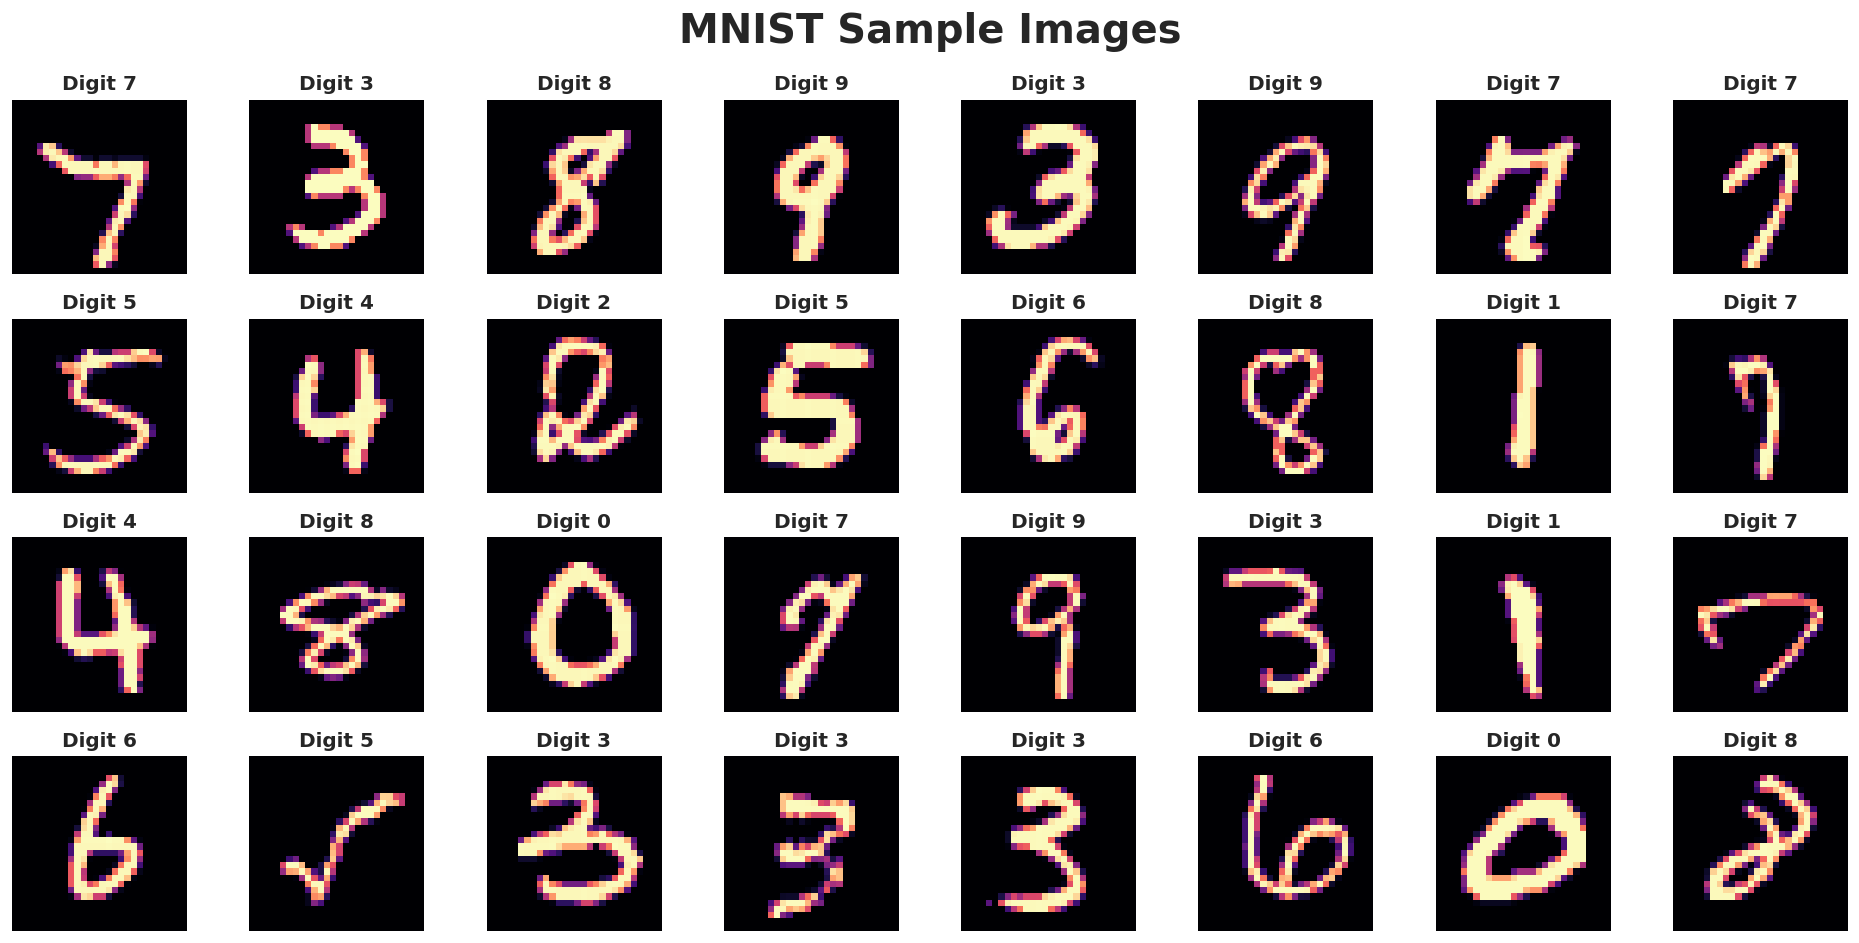

'images/MNIST_Sample_Images.png'

In [8]:
fig, axes = plt.subplots(
    4,
    8,
    figsize=(16, 8)
)

indices = np.random.choice(
    len(X_train),
    32,
    replace=False
)

for ax, idx in zip(
    axes.ravel(),
    indices
):
    ax.imshow(
        X_train[idx],
        cmap="magma"
    )

    ax.set_title(
        f"Digit {y_train[idx]}",
        fontsize=12,
        fontweight="bold"
    )

    ax.axis("off")

title = "MNIST Sample Images"

fig.suptitle(
    title,
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

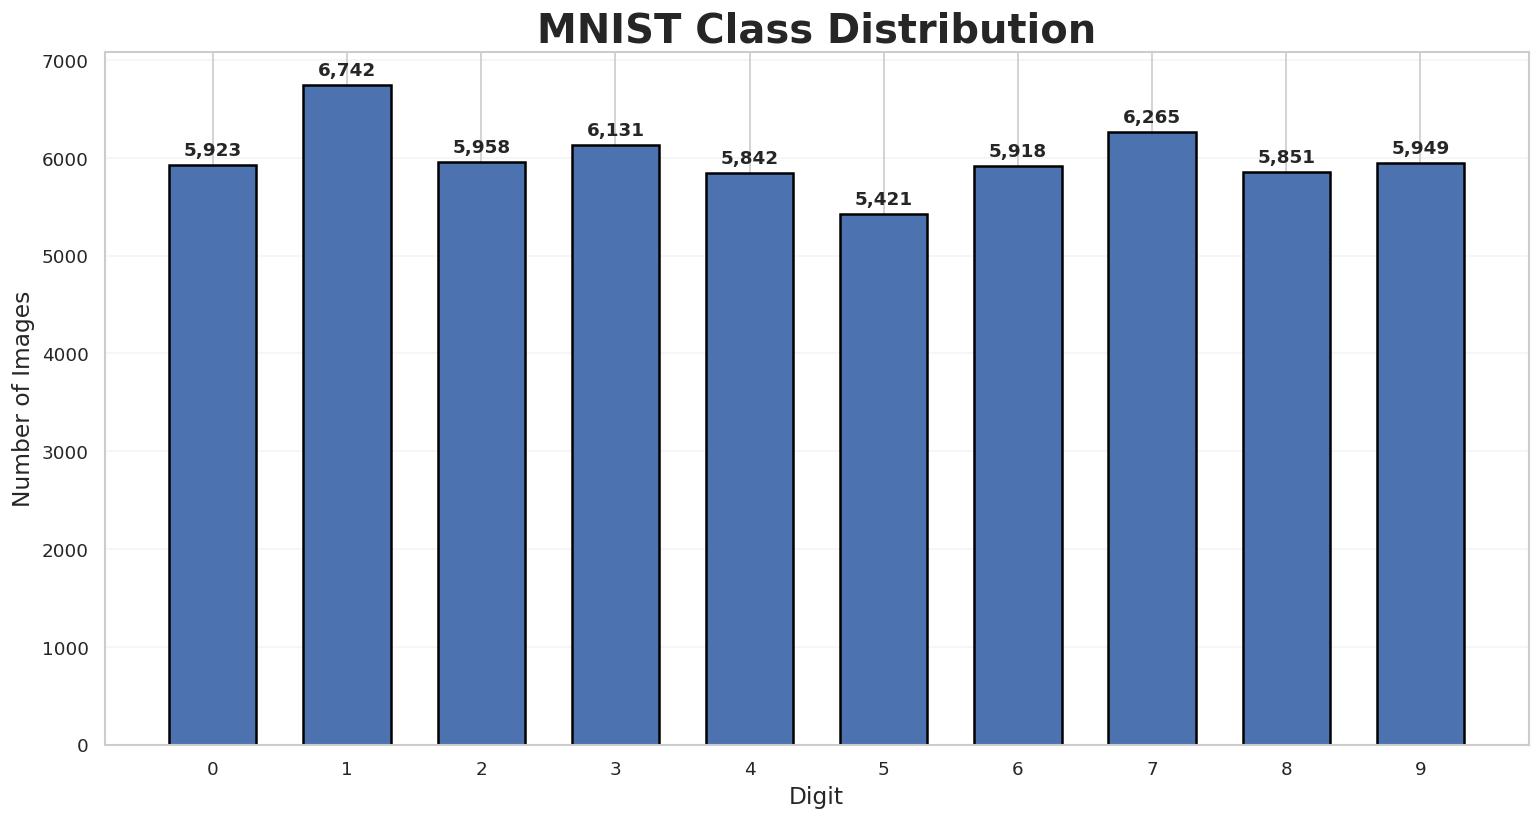

'images/MNIST_Class_Distribution.png'

In [9]:
class_counts = np.bincount(y_train)

fig, ax = plt.subplots(
    figsize=(13, 7)
)

bars = ax.bar(
    range(10),
    class_counts,
    width=0.65,
    edgecolor="black",
    linewidth=1.5
)

ax.set_title(
    "MNIST Class Distribution",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Digit",
    fontsize=14
)

ax.set_ylabel(
    "Number of Images",
    fontsize=14
)

ax.set_xticks(range(10))

for bar, value in zip(
    bars,
    class_counts
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 100,
        f"{value:,}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.2
)

title = "MNIST Class Distribution"

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

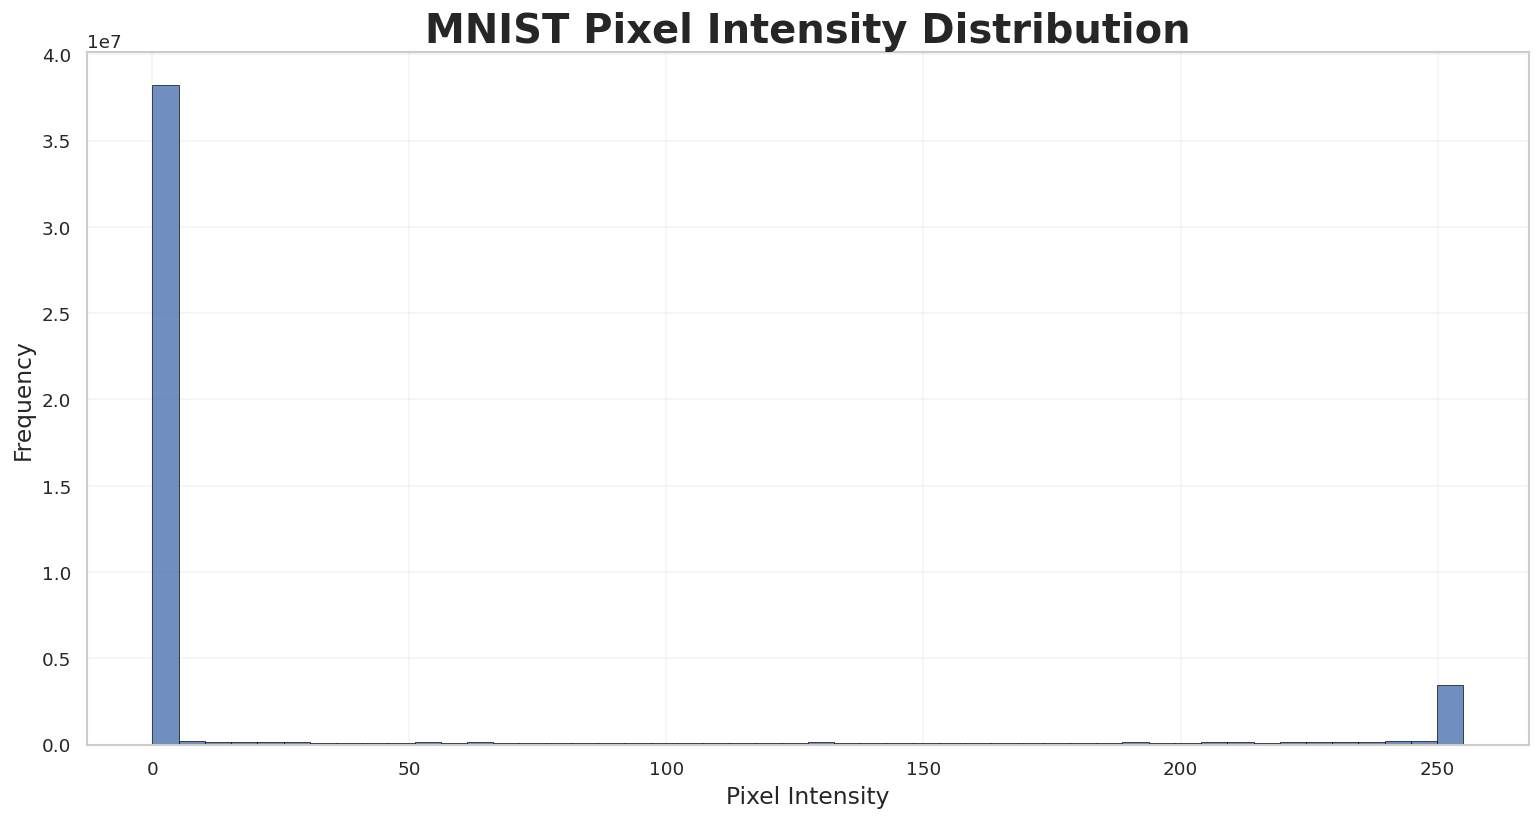

'images/MNIST_Pixel_Intensity_Distribution.png'

In [10]:
fig, ax = plt.subplots(
    figsize=(13, 7)
)

ax.hist(
    X_train.reshape(-1),
    bins=50,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5
)

title = "MNIST Pixel Intensity Distribution"

ax.set_title(
    title,
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Pixel Intensity",
    fontsize=14
)

ax.set_ylabel(
    "Frequency",
    fontsize=14
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [11]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print(
    "Training range:",
    X_train_norm.min(),
    "to",
    X_train_norm.max()
)

print(
    "Testing range:",
    X_test_norm.min(),
    "to",
    X_test_norm.max()
)

Training range: 0.0 to 1.0
Testing range: 0.0 to 1.0


In [12]:
X_train_ann = X_train_norm.reshape(
    -1,
    784
)

X_test_ann = X_test_norm.reshape(
    -1,
    784
)

print(
    "ANN Training Shape:",
    X_train_ann.shape
)

print(
    "ANN Testing Shape:",
    X_test_ann.shape
)

ANN Training Shape: (60000, 784)
ANN Testing Shape: (10000, 784)


In [13]:
X_train_cnn = X_train_norm[..., np.newaxis]
X_test_cnn = X_test_norm[..., np.newaxis]

print(
    "CNN Training Shape:",
    X_train_cnn.shape
)

print(
    "CNN Testing Shape:",
    X_test_cnn.shape
)

CNN Training Shape: (60000, 28, 28, 1)
CNN Testing Shape: (10000, 28, 28, 1)


In [14]:
ann = Sequential([
    Input(shape=(784,)),
    Dense(512, activation="relu"),
    Dropout(0.25),
    Dense(256, activation="relu"),
    Dropout(0.20),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

ann.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
ann_params = ann.count_params()

print(
    "ANN Total Parameters:",
    f"{ann_params:,}"
)

ANN Total Parameters: 567,434


In [16]:
ann_start = time.perf_counter()

ann_history = ann.fit(
    X_train_ann,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

ann_training_time = (
    time.perf_counter() - ann_start
)

print(
    f"ANN Training Time: "
    f"{ann_training_time:.2f} seconds"
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9112 - loss: 0.2920 - val_accuracy: 0.9690 - val_loss: 0.0975
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9619 - loss: 0.1217 - val_accuracy: 0.9777 - val_loss: 0.0750
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9727 - loss: 0.0866 - val_accuracy: 0.9785 - val_loss: 0.0702
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9784 - loss: 0.0684 - val_accuracy: 0.9768 - val_loss: 0.0807
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9804 - loss: 0.0599 - val_accuracy: 0.9803 - val_loss: 0.0719
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9829 - loss: 0.0508 - val_accuracy: 0.9797 - val_loss: 0.0746
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9864 - loss: 0.0438 - val_accuracy: 0.9783 - val_loss: 0.0765
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9867 - loss: 0.0413 - val_accuracy: 

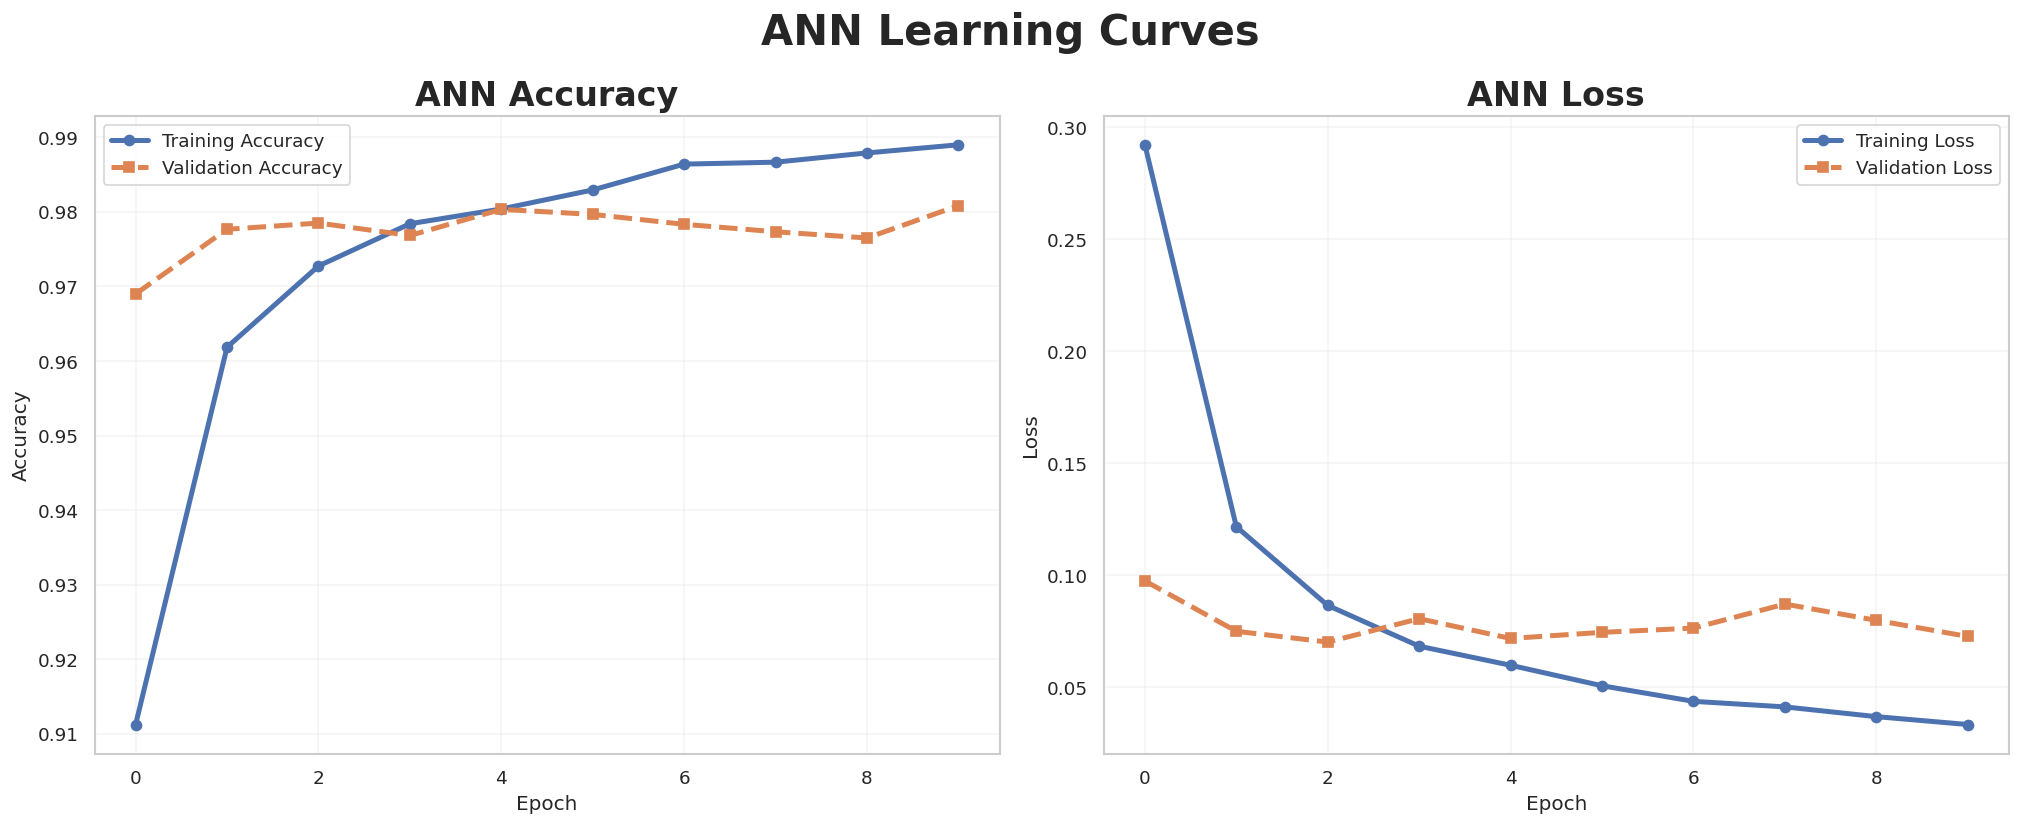

'images/ANN_Learning_Curves.png'

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 7)
)

axes[0].plot(
    ann_history.history["accuracy"],
    marker="o",
    linewidth=3,
    label="Training Accuracy"
)

axes[0].plot(
    ann_history.history["val_accuracy"],
    marker="s",
    linewidth=3,
    linestyle="--",
    label="Validation Accuracy"
)

axes[0].set_title(
    "ANN Accuracy",
    fontsize=20,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(
    ann_history.history["loss"],
    marker="o",
    linewidth=3,
    label="Training Loss"
)

axes[1].plot(
    ann_history.history["val_loss"],
    marker="s",
    linewidth=3,
    linestyle="--",
    label="Validation Loss"
)

axes[1].set_title(
    "ANN Loss",
    fontsize=20,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.2)

title = "ANN Learning Curves"

fig.suptitle(
    title,
    fontsize=25,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [18]:
ann_test_loss, ann_test_accuracy = ann.evaluate(
    X_test_ann,
    y_test,
    verbose=0
)

print(
    f"ANN Test Loss: {ann_test_loss:.6f}"
)

print(
    f"ANN Test Accuracy: "
    f"{ann_test_accuracy:.4%}"
)

ANN Test Loss: 0.075703
ANN Test Accuracy: 97.9600%


In [19]:
cnn = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Dropout(0.25),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        10,
        activation="softmax"
    )
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,818 (1.92 MB)

 Trainable params: 503,754 (1.92 MB)

 Non-trainable params: 64 (256.00 B)

In [20]:
cnn_params = cnn.count_params()

print(
    "CNN Total Parameters:",
    f"{cnn_params:,}"
)

CNN Total Parameters: 503,818


In [21]:
cnn_start = time.perf_counter()

cnn_history = cnn.fit(
    X_train_cnn,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

cnn_training_time = (
    time.perf_counter() - cnn_start
)

print(
    f"CNN Training Time: "
    f"{cnn_training_time:.2f} seconds"
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9287 - loss: 0.2299 - val_accuracy: 0.9887 - val_loss: 0.1204
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9797 - loss: 0.0654 - val_accuracy: 0.9907 - val_loss: 0.0329
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9858 - loss: 0.0470 - val_accuracy: 0.9920 - val_loss: 0.0271
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9880 - loss: 0.0392 - val_accuracy: 0.9923 - val_loss: 0.0284
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9900 - loss: 0.0317 - val_accuracy: 0.9913 - val_loss: 0.0294
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9917 - loss: 0.0265 - val_accuracy: 0.9922 - val_loss: 0.0291
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 0.9920 - val_loss: 0.0280
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9927 - loss: 0.0217 - val_accur

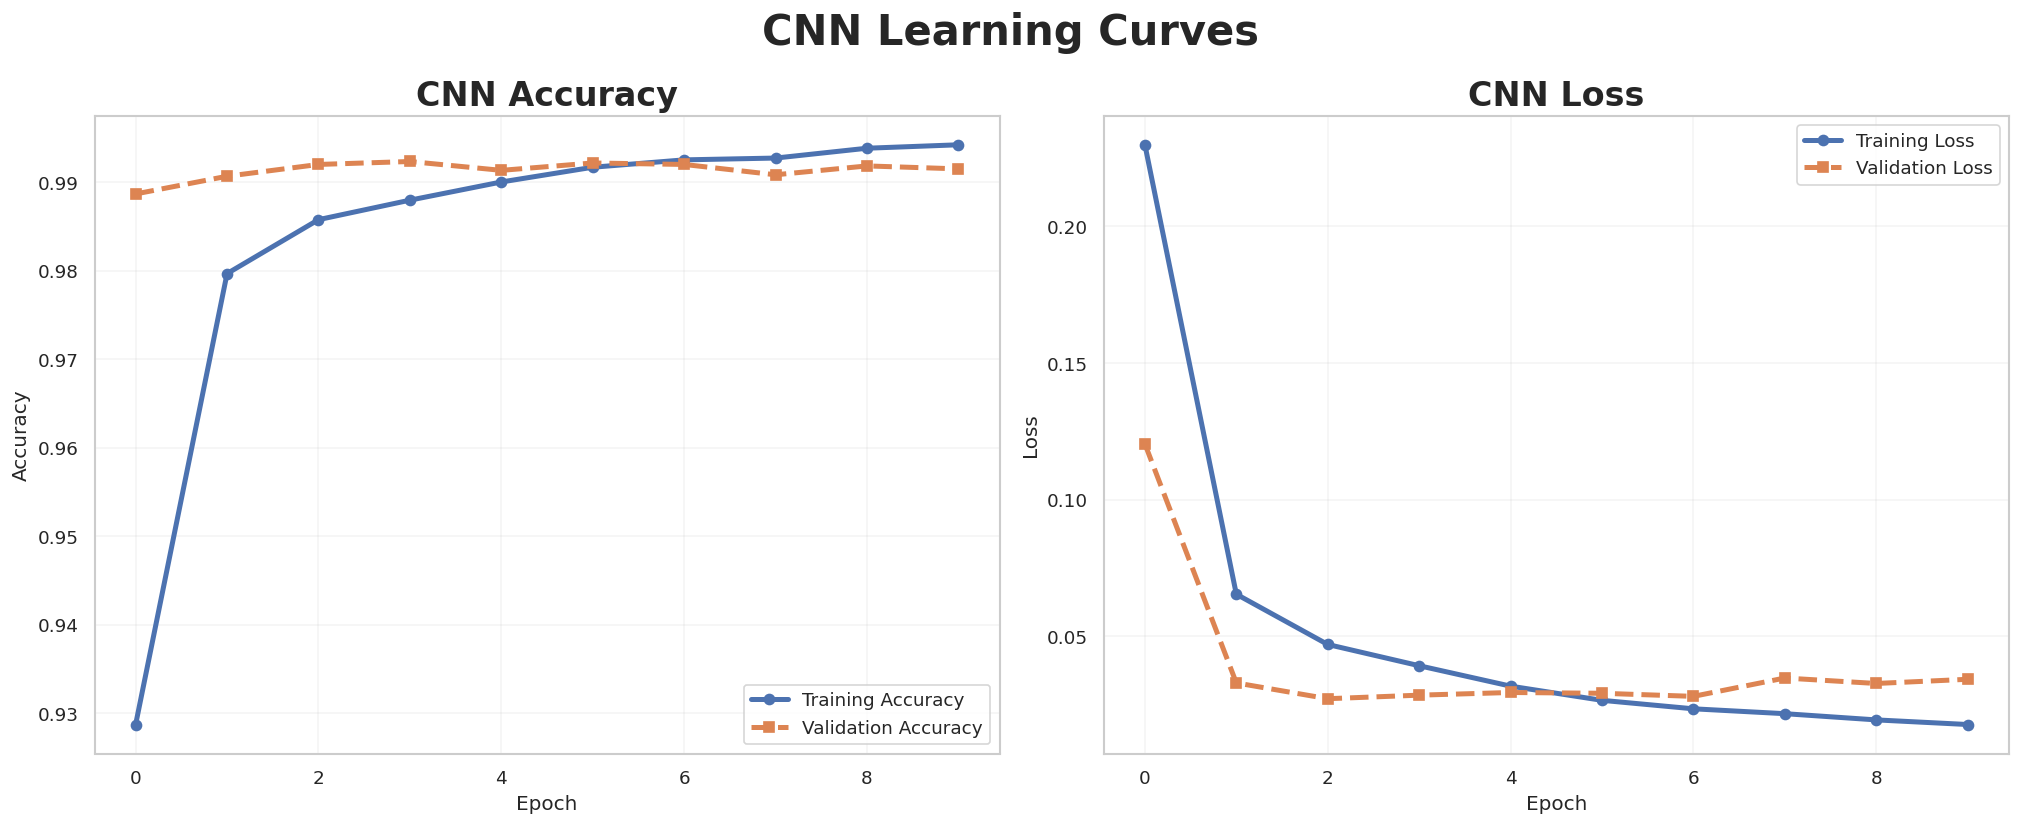

'images/CNN_Learning_Curves.png'

In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 7)
)

axes[0].plot(
    cnn_history.history["accuracy"],
    marker="o",
    linewidth=3,
    label="Training Accuracy"
)

axes[0].plot(
    cnn_history.history["val_accuracy"],
    marker="s",
    linewidth=3,
    linestyle="--",
    label="Validation Accuracy"
)

axes[0].set_title(
    "CNN Accuracy",
    fontsize=20,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(
    cnn_history.history["loss"],
    marker="o",
    linewidth=3,
    label="Training Loss"
)

axes[1].plot(
    cnn_history.history["val_loss"],
    marker="s",
    linewidth=3,
    linestyle="--",
    label="Validation Loss"
)

axes[1].set_title(
    "CNN Loss",
    fontsize=20,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.2)

title = "CNN Learning Curves"

fig.suptitle(
    title,
    fontsize=25,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [23]:
cnn_test_loss, cnn_test_accuracy = cnn.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print(
    f"CNN Test Loss: {cnn_test_loss:.6f}"
)

print(
    f"CNN Test Accuracy: "
    f"{cnn_test_accuracy:.4%}"
)

CNN Test Loss: 0.023181
CNN Test Accuracy: 99.2800%


In [24]:
comparison_df = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN"
    ],
    "Parameters": [
        ann_params,
        cnn_params
    ],
    "Training Time (sec)": [
        ann_training_time,
        cnn_training_time
    ],
    "Test Loss": [
        ann_test_loss,
        cnn_test_loss
    ],
    "Test Accuracy": [
        ann_test_accuracy,
        cnn_test_accuracy
    ]
})

display(
    comparison_df.style.format({
        "Parameters": "{:,.0f}",
        "Training Time (sec)": "{:.2f}",
        "Test Loss": "{:.5f}",
        "Test Accuracy": "{:.4%}"
    })
)

,Model,Parameters,Training Time (sec),Test Loss,Test Accuracy
0,ANN,"567,434",36.98,0.07570,97.9600%
1,CNN,"503,818",52.11,0.02318,99.2800%


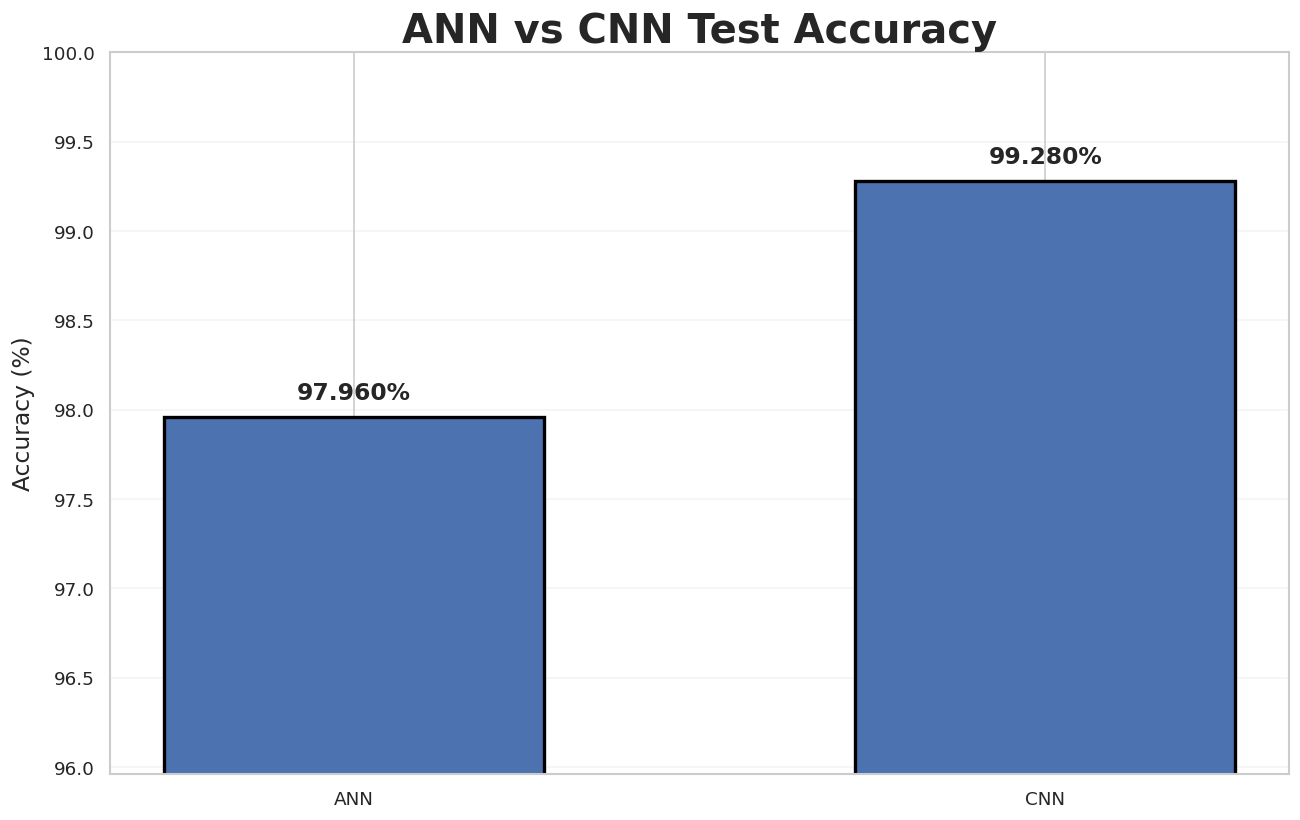

'images/ANN_vs_CNN_Test_Accuracy.png'

In [25]:
models = ["ANN", "CNN"]

accuracy_values = [
    ann_test_accuracy * 100,
    cnn_test_accuracy * 100
]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.bar(
    models,
    accuracy_values,
    width=0.55,
    edgecolor="black",
    linewidth=2
)

title = "ANN vs CNN Test Accuracy"

ax.set_title(
    title,
    fontsize=24,
    fontweight="bold"
)

ax.set_ylabel(
    "Accuracy (%)",
    fontsize=14
)

ax.set_ylim(
    min(accuracy_values) - 2,
    100
)

for bar, value in zip(
    bars,
    accuracy_values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        f"{value:.3f}%",
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

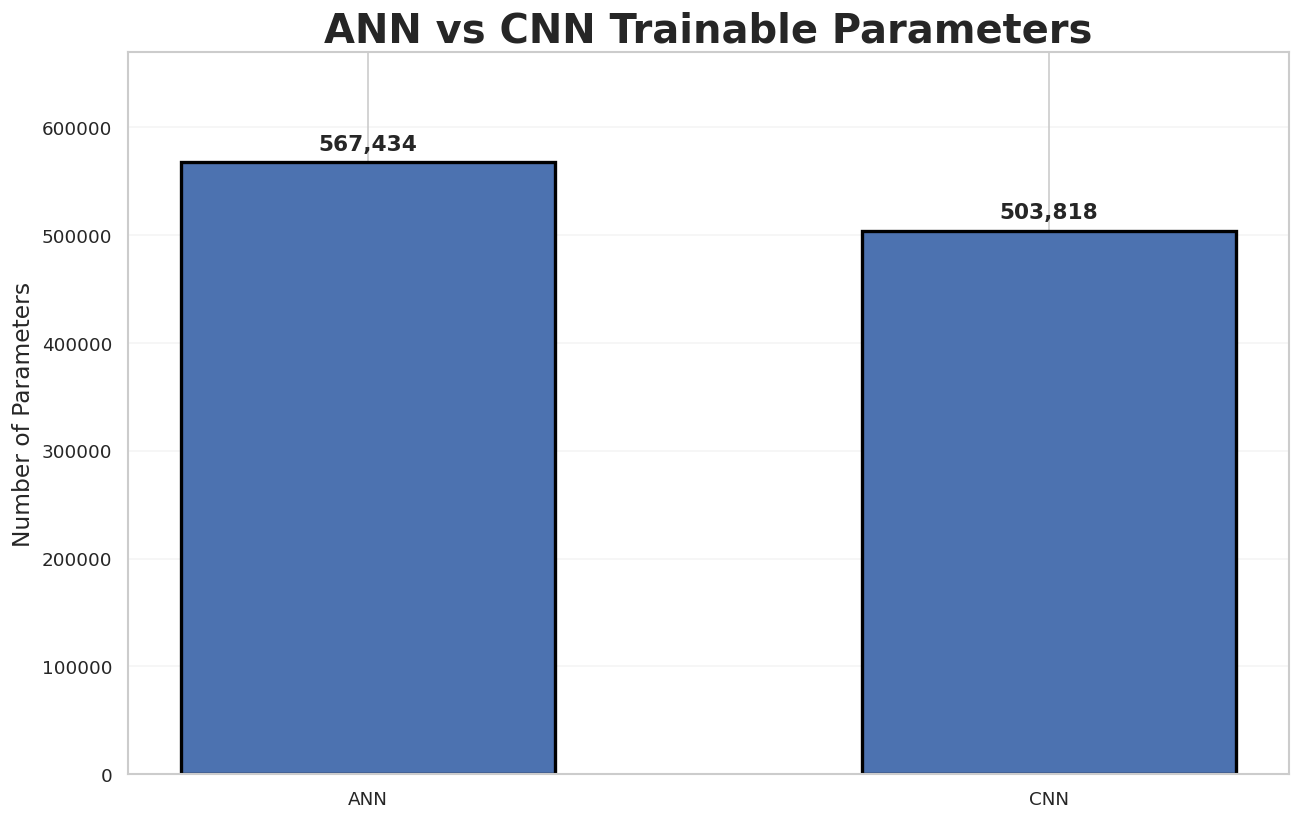

'images/ANN_vs_CNN_Trainable_Parameters.png'

In [26]:
parameter_values = [
    ann_params,
    cnn_params
]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.bar(
    models,
    parameter_values,
    width=0.55,
    edgecolor="black",
    linewidth=2
)

title = "ANN vs CNN Trainable Parameters"

ax.set_title(
    title,
    fontsize=24,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Parameters",
    fontsize=14
)

ax.set_ylim(0, max(parameter_values) * 1.18)

for bar, value in zip(
    bars,
    parameter_values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (max(parameter_values) * 0.02),
        f"{value:,}",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

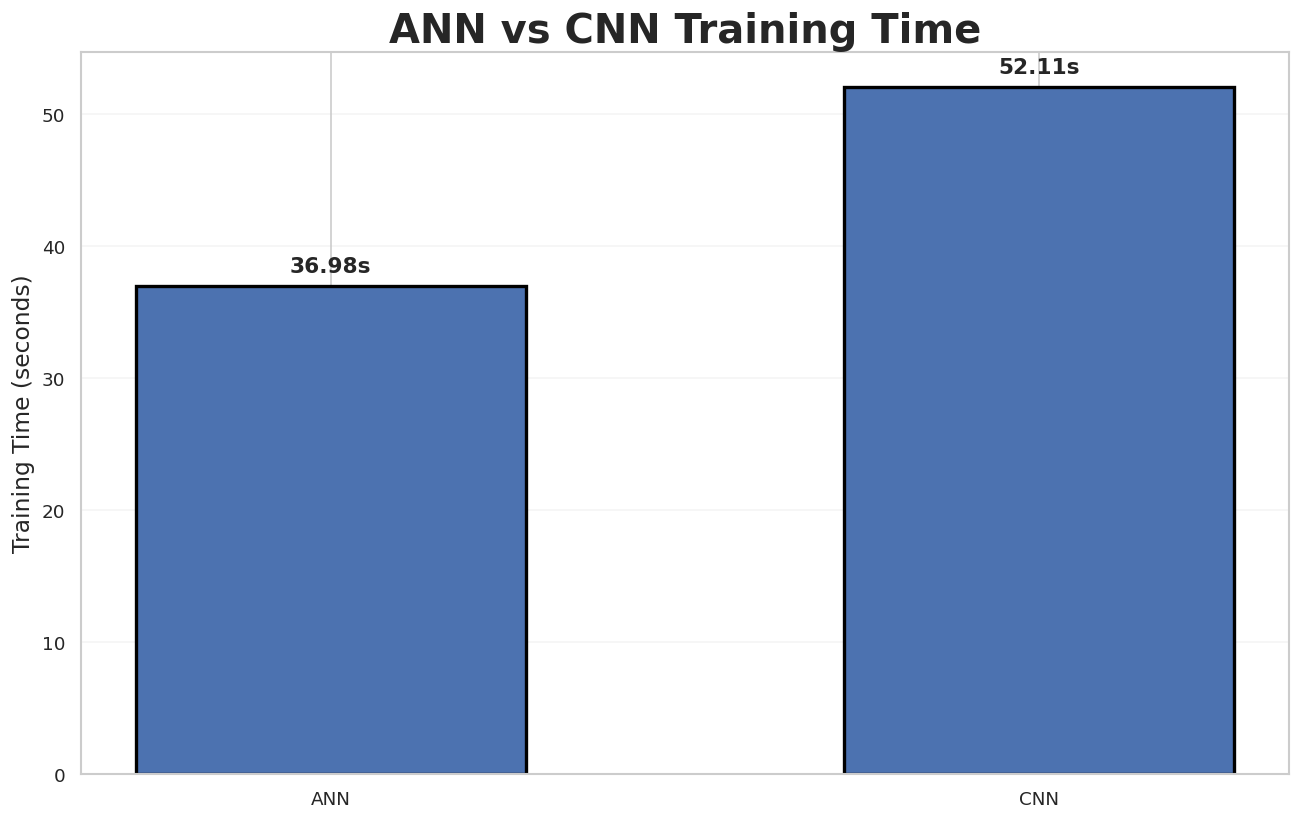

'images/ANN_vs_CNN_Training_Time.png'

In [27]:
training_times = [
    ann_training_time,
    cnn_training_time
]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.bar(
    models,
    training_times,
    width=0.55,
    edgecolor="black",
    linewidth=2
)

title = "ANN vs CNN Training Time"

ax.set_title(
    title,
    fontsize=24,
    fontweight="bold"
)

ax.set_ylabel(
    "Training Time (seconds)",
    fontsize=14
)

for bar, value in zip(
    bars,
    training_times
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(training_times) * 0.02,
        f"{value:.2f}s",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

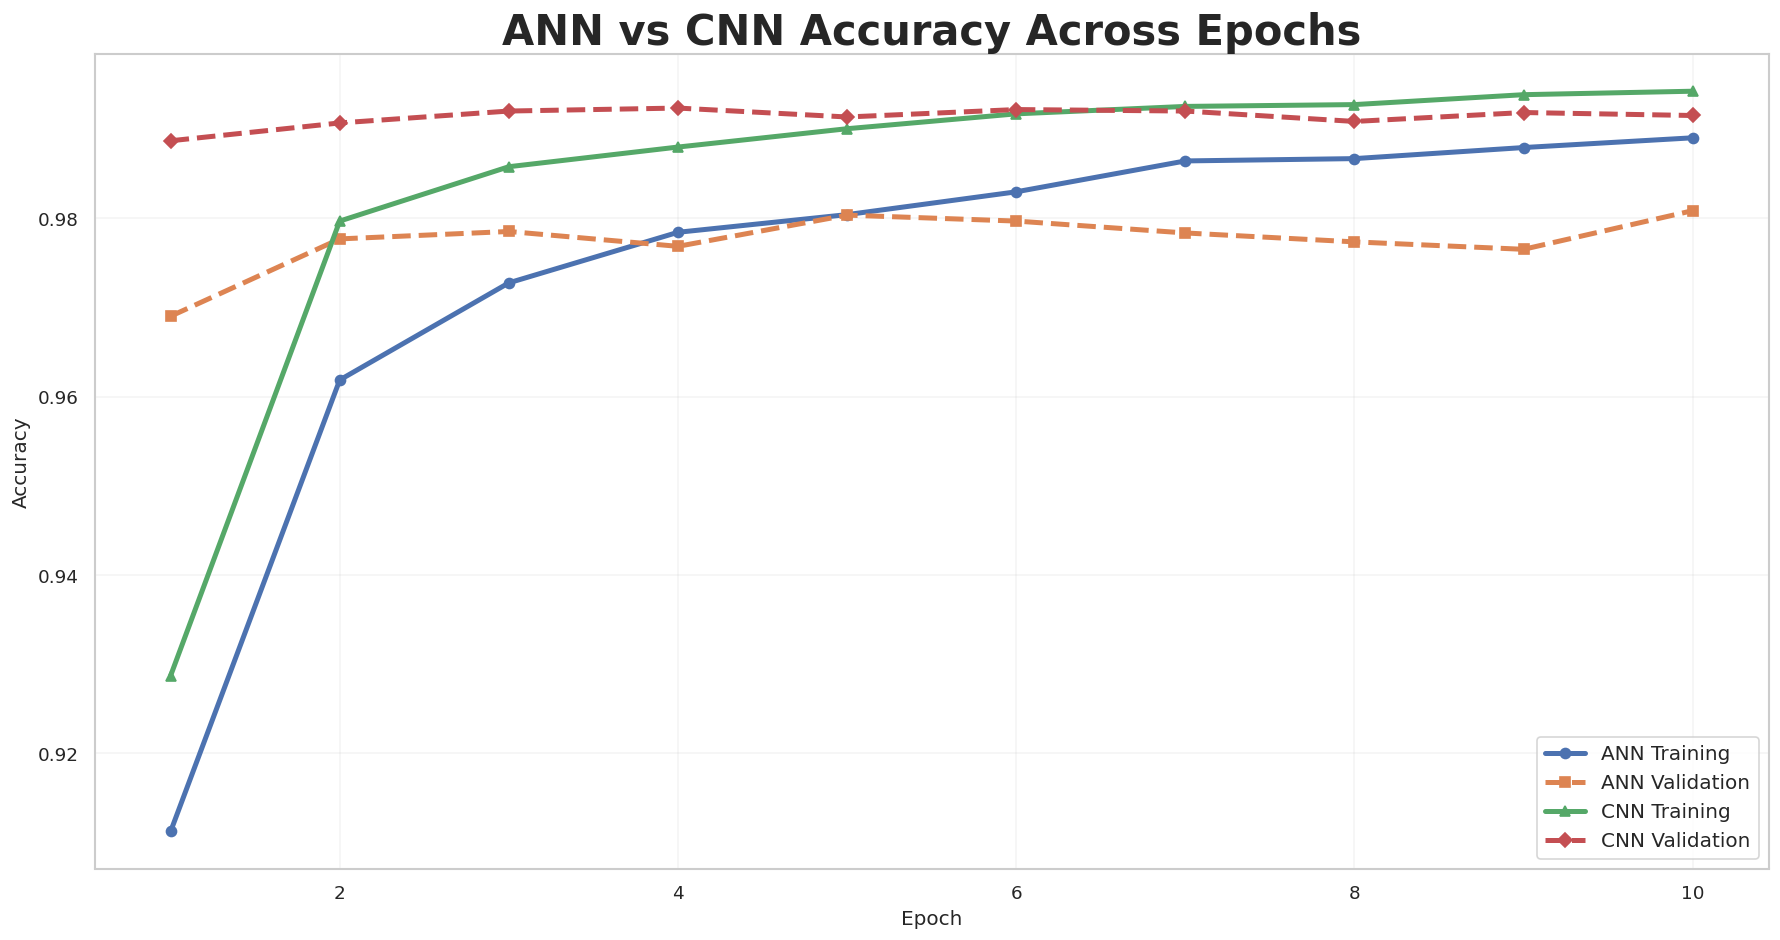

'images/ANN_vs_CNN_Accuracy_Across_Epochs.png'

In [28]:
fig, ax = plt.subplots(
    figsize=(15, 8)
)

epochs_ann = range(
    1,
    len(ann_history.history["accuracy"]) + 1
)

epochs_cnn = range(
    1,
    len(cnn_history.history["accuracy"]) + 1
)

ax.plot(
    epochs_ann,
    ann_history.history["accuracy"],
    marker="o",
    linewidth=3,
    label="ANN Training"
)

ax.plot(
    epochs_ann,
    ann_history.history["val_accuracy"],
    marker="s",
    linewidth=3,
    linestyle="--",
    label="ANN Validation"
)

ax.plot(
    epochs_cnn,
    cnn_history.history["accuracy"],
    marker="^",
    linewidth=3,
    label="CNN Training"
)

ax.plot(
    epochs_cnn,
    cnn_history.history["val_accuracy"],
    marker="D",
    linewidth=3,
    linestyle="--",
    label="CNN Validation"
)

title = "ANN vs CNN Accuracy Across Epochs"

ax.set_title(
    title,
    fontsize=25,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.legend(
    fontsize=12
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

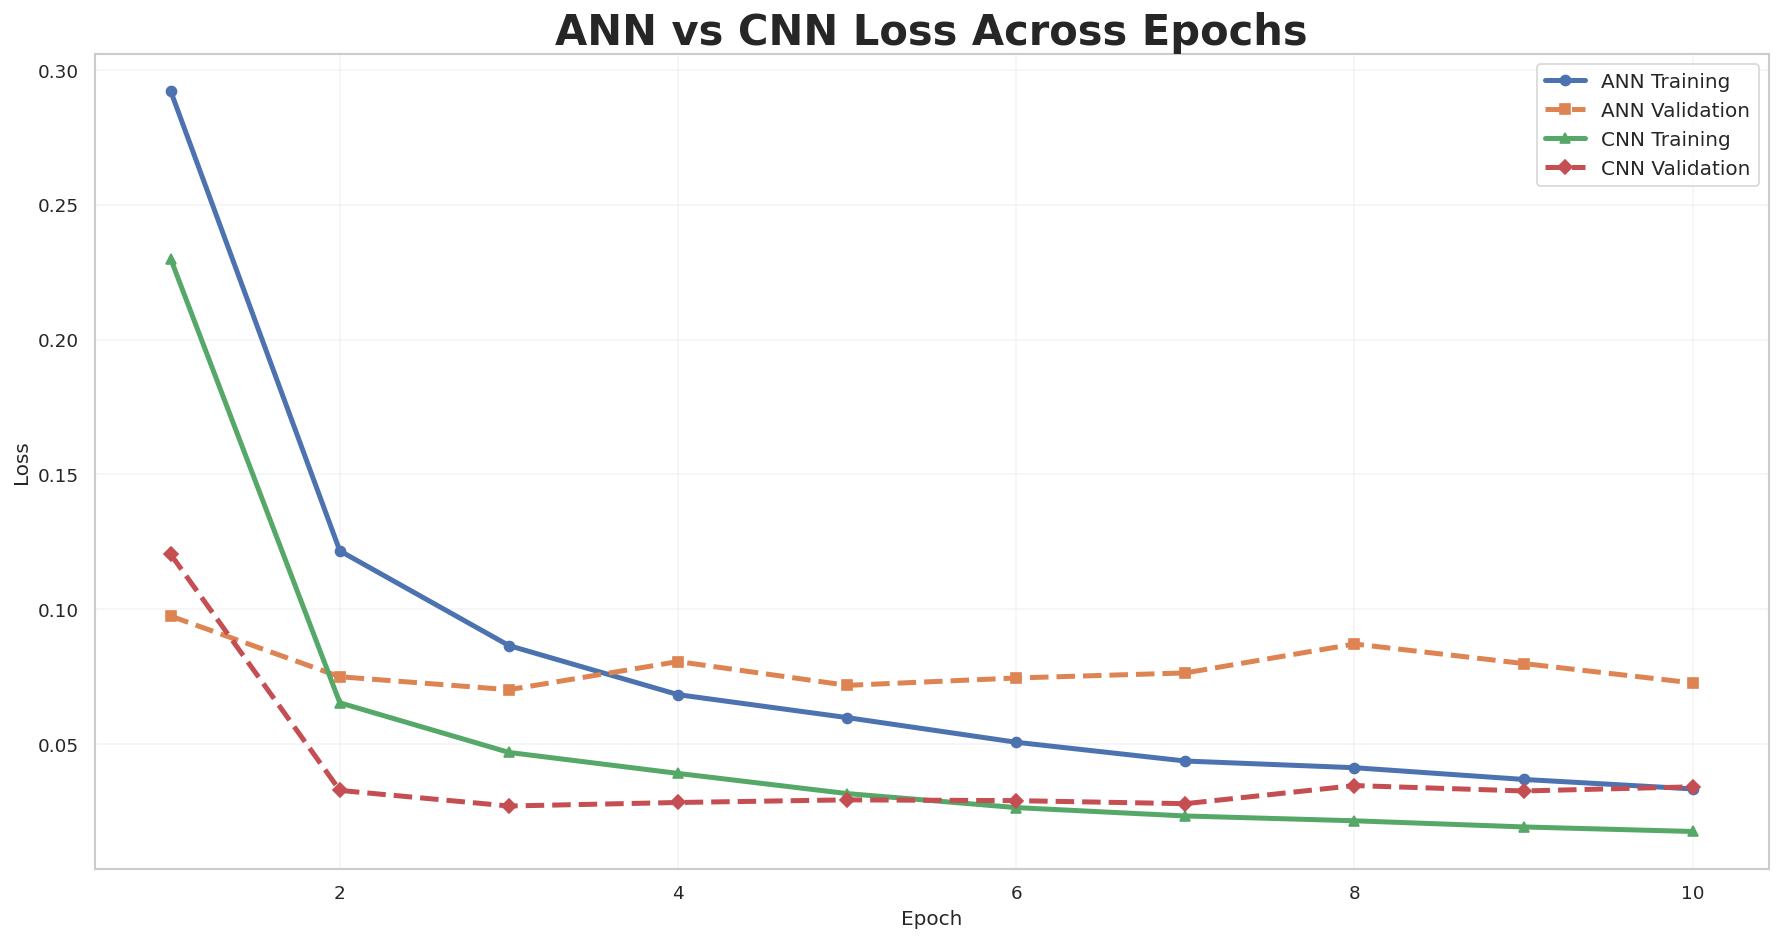

'images/ANN_vs_CNN_Loss_Across_Epochs.png'

In [29]:
fig, ax = plt.subplots(
    figsize=(15, 8)
)

ax.plot(
    epochs_ann,
    ann_history.history["loss"],
    marker="o",
    linewidth=3,
    label="ANN Training"
)

ax.plot(
    epochs_ann,
    ann_history.history["val_loss"],
    marker="s",
    linewidth=3,
    linestyle="--",
    label="ANN Validation"
)

ax.plot(
    epochs_cnn,
    cnn_history.history["loss"],
    marker="^",
    linewidth=3,
    label="CNN Training"
)

ax.plot(
    epochs_cnn,
    cnn_history.history["val_loss"],
    marker="D",
    linewidth=3,
    linestyle="--",
    label="CNN Validation"
)

title = "ANN vs CNN Loss Across Epochs"

ax.set_title(
    title,
    fontsize=25,
    fontweight="bold"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

ax.legend(
    fontsize=12
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [30]:
ann_probabilities = ann.predict(
    X_test_ann,
    verbose=0
)

cnn_probabilities = cnn.predict(
    X_test_cnn,
    verbose=0
)

ann_predictions = np.argmax(
    ann_probabilities,
    axis=1
)

cnn_predictions = np.argmax(
    cnn_probabilities,
    axis=1
)

print(
    "ANN Prediction Shape:",
    ann_predictions.shape
)

print(
    "CNN Prediction Shape:",
    cnn_predictions.shape
)

ANN Prediction Shape: (10000,)
CNN Prediction Shape: (10000,)


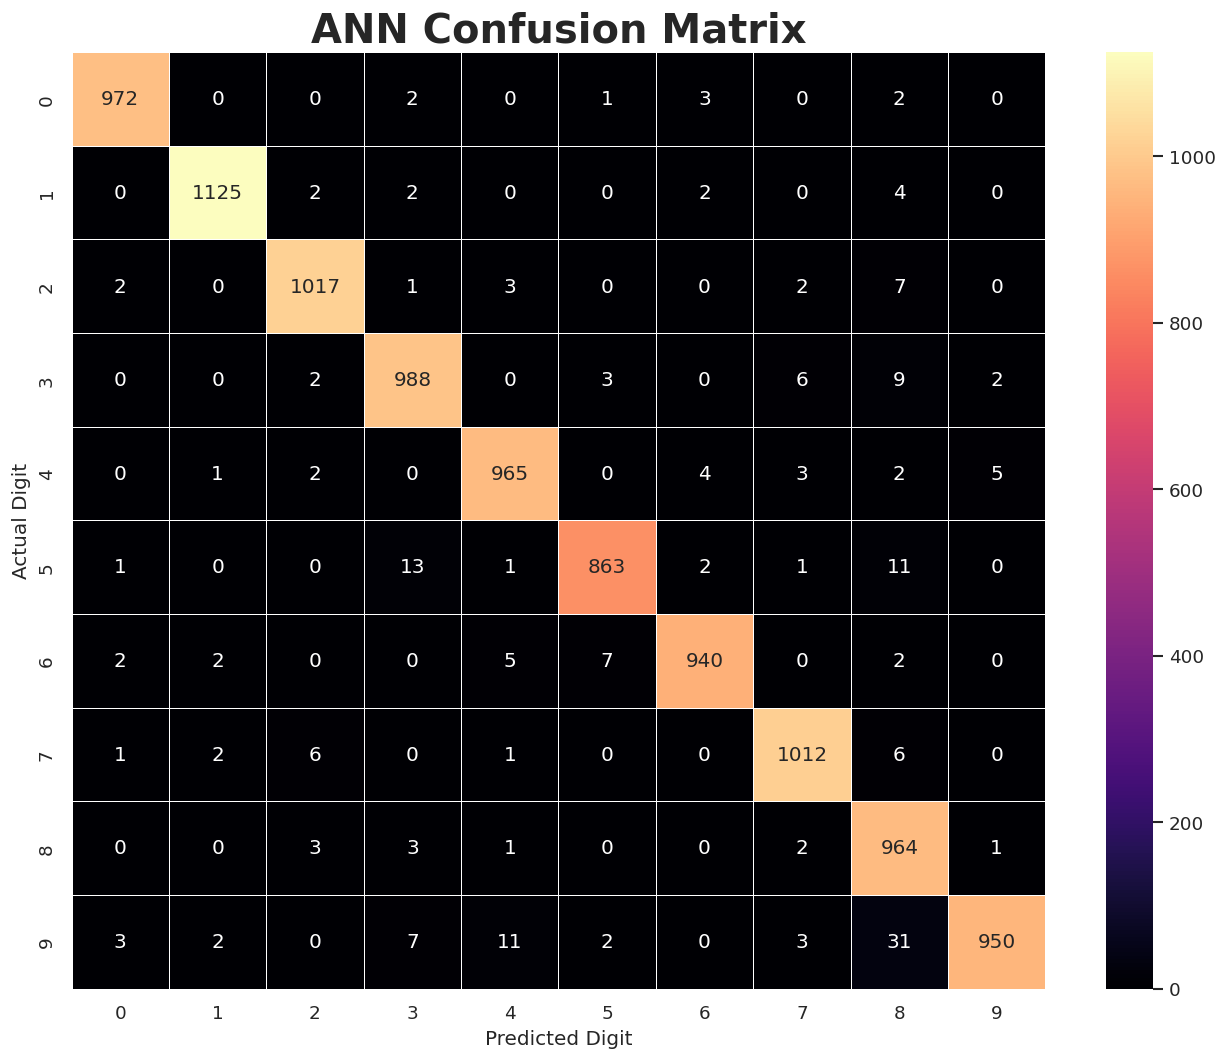

'images/ANN_Confusion_Matrix.png'

In [31]:
ann_cm = confusion_matrix(
    y_test,
    ann_predictions
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

sns.heatmap(
    ann_cm,
    annot=True,
    fmt="d",
    cmap="magma",
    linewidths=0.5,
    ax=ax
)

title = "ANN Confusion Matrix"

ax.set_title(
    title,
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel("Predicted Digit")
ax.set_ylabel("Actual Digit")

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

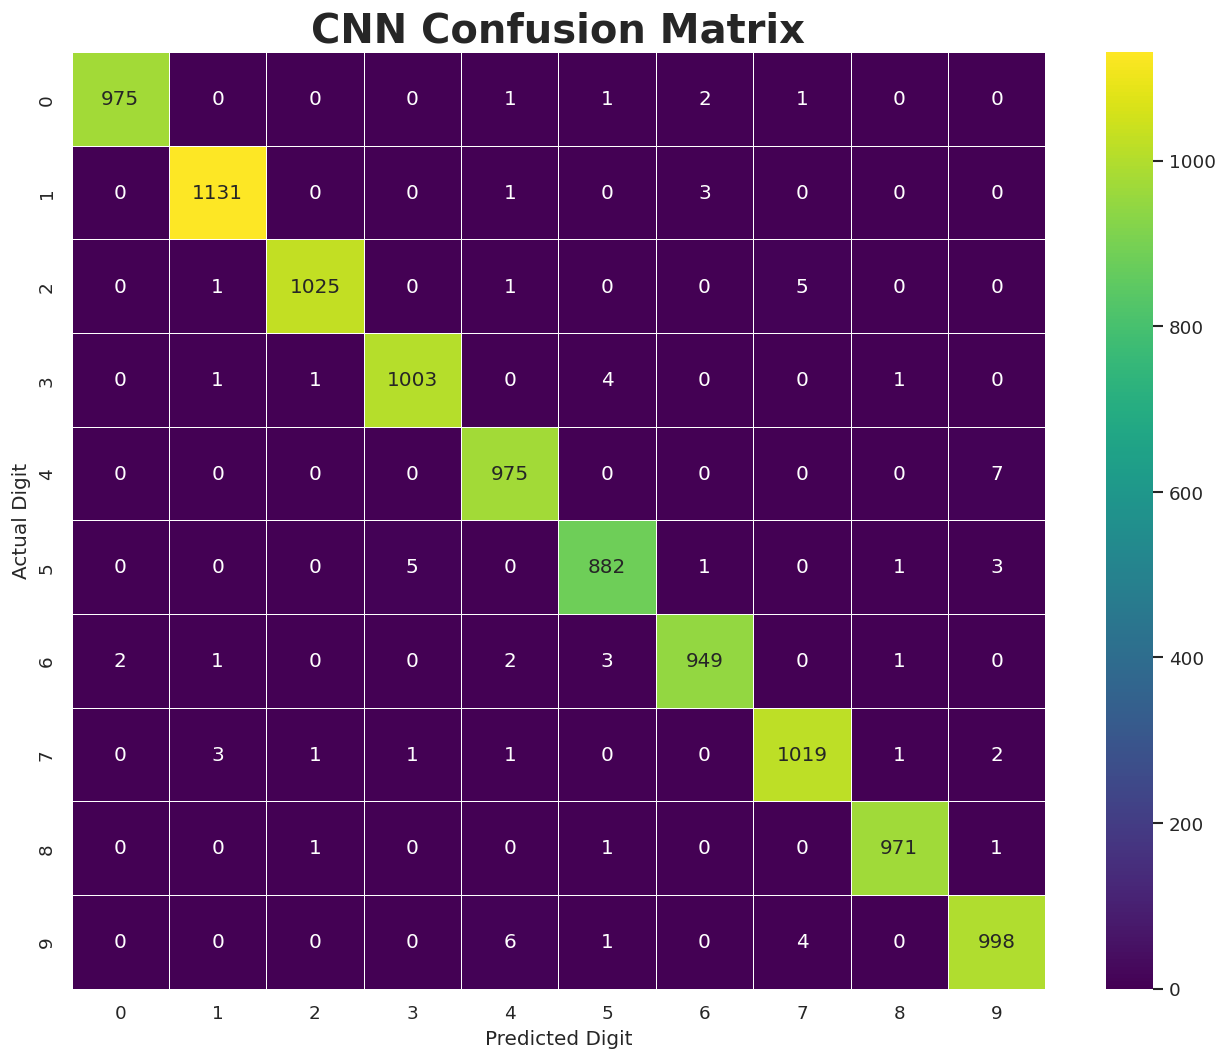

'images/CNN_Confusion_Matrix.png'

In [32]:
cnn_cm = confusion_matrix(
    y_test,
    cnn_predictions
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=0.5,
    ax=ax
)

title = "CNN Confusion Matrix"

ax.set_title(
    title,
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel("Predicted Digit")
ax.set_ylabel("Actual Digit")

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [33]:
ann_report = classification_report(
    y_test,
    ann_predictions,
    output_dict=True
)

cnn_report = classification_report(
    y_test,
    cnn_predictions,
    output_dict=True
)

print("ANN")
print(
    classification_report(
        y_test,
        ann_predictions,
        digits=4
    )
)

print("CNN")
print(
    classification_report(
        y_test,
        cnn_predictions,
        digits=4
    )
)

ANN
              precision    recall  f1-score   support

           0     0.9908    0.9918    0.9913       980
           1     0.9938    0.9912    0.9925      1135
           2     0.9855    0.9855    0.9855      1032
           3     0.9724    0.9782    0.9753      1010
           4     0.9777    0.9827    0.9802       982
           5     0.9852    0.9675    0.9762       892
           6     0.9884    0.9812    0.9848       958
           7     0.9835    0.9844    0.9840      1028
           8     0.9287    0.9897    0.9583       974
           9     0.9916    0.9415    0.9659      1009

    accuracy                         0.9796     10000
   macro avg     0.9798    0.9794    0.9794     10000
weighted avg     0.9800    0.9796    0.9796     10000

CNN
              precision    recall  f1-score   support

           0     0.9980    0.9949    0.9964       980
           1     0.9947    0.9965    0.9956      1135
           2     0.9971    0.9932    0.9951      1032
           3    

In [34]:
ann_digit_accuracy = []
cnn_digit_accuracy = []

for digit in range(10):
    mask = y_test == digit

    ann_digit_accuracy.append(
        accuracy_score(
            y_test[mask],
            ann_predictions[mask]
        )
    )

    cnn_digit_accuracy.append(
        accuracy_score(
            y_test[mask],
            cnn_predictions[mask]
        )
    )

digit_accuracy_df = pd.DataFrame({
    "Digit": range(10),
    "ANN Accuracy": ann_digit_accuracy,
    "CNN Accuracy": cnn_digit_accuracy
})

display(
    digit_accuracy_df.style.format({
        "ANN Accuracy": "{:.4%}",
        "CNN Accuracy": "{:.4%}"
    })
)

,Digit,ANN Accuracy,CNN Accuracy
0,0,99.1837%,99.4898%
1,1,99.1189%,99.6476%
2,2,98.5465%,99.3217%
3,3,97.8218%,99.3069%
4,4,98.2688%,99.2872%
5,5,96.7489%,98.8789%
6,6,98.1211%,99.0605%
7,7,98.4436%,99.1245%
8,8,98.9733%,99.6920%
9,9,94.1526%,98.9098%


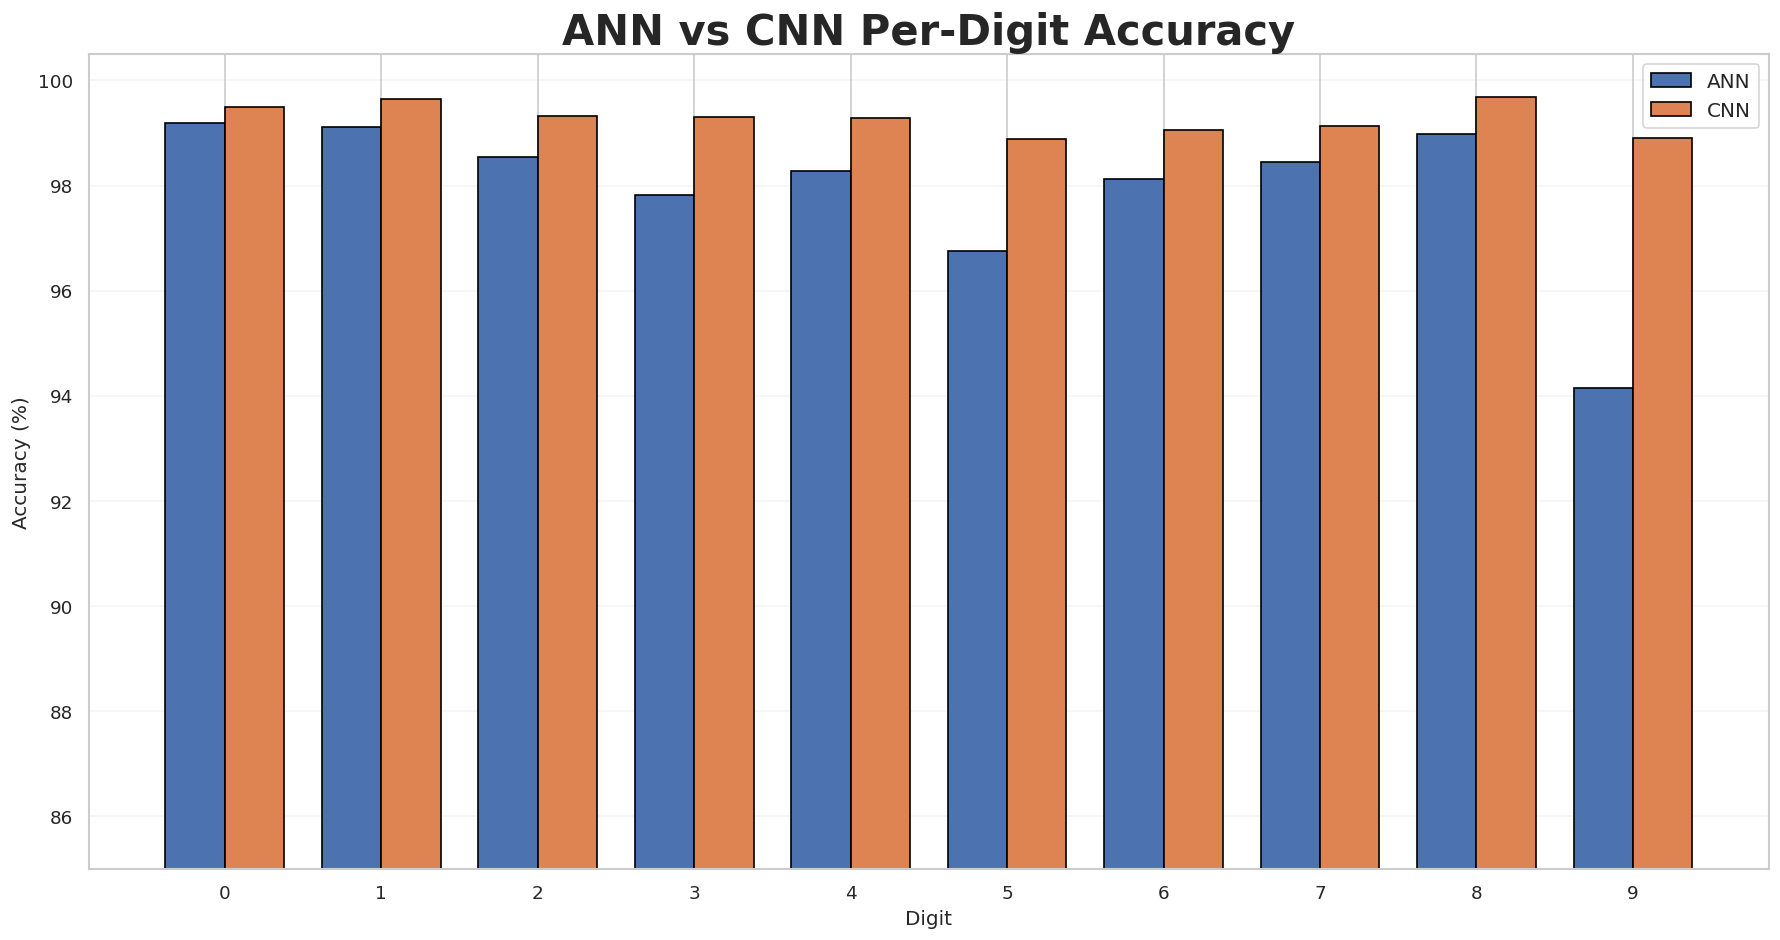

'images/ANN_vs_CNN_Per-Digit_Accuracy.png'

In [35]:
x = np.arange(10)
width = 0.38

fig, ax = plt.subplots(
    figsize=(15, 8)
)

ax.bar(
    x - width / 2,
    np.array(ann_digit_accuracy) * 100,
    width,
    label="ANN",
    edgecolor="black"
)

ax.bar(
    x + width / 2,
    np.array(cnn_digit_accuracy) * 100,
    width,
    label="CNN",
    edgecolor="black"
)

title = "ANN vs CNN Per-Digit Accuracy"

ax.set_title(
    title,
    fontsize=25,
    fontweight="bold"
)

ax.set_xlabel("Digit")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(range(10))
ax.set_ylim(85, 100.5)

ax.legend(
    fontsize=12
)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

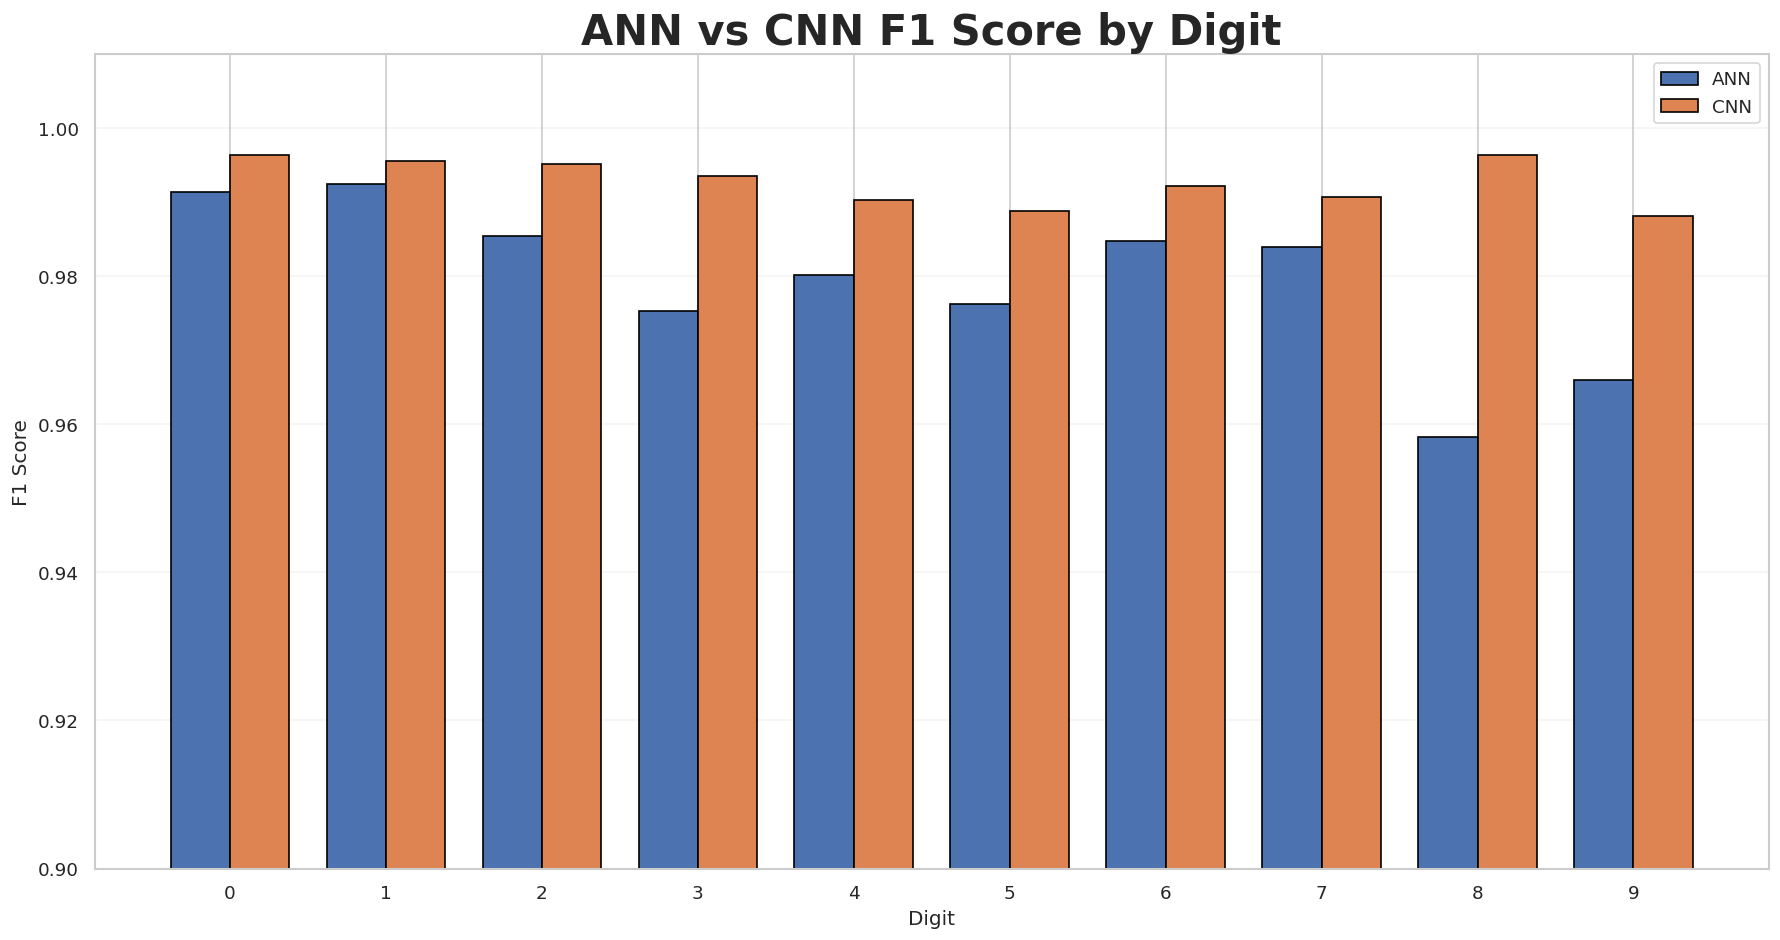

'images/ANN_vs_CNN_F1_Score_by_Digit.png'

In [36]:
ann_f1 = [
    ann_report[str(i)]["f1-score"]
    for i in range(10)
]

cnn_f1 = [
    cnn_report[str(i)]["f1-score"]
    for i in range(10)
]

fig, ax = plt.subplots(
    figsize=(15, 8)
)

ax.bar(
    x - width / 2,
    ann_f1,
    width,
    label="ANN",
    edgecolor="black"
)

ax.bar(
    x + width / 2,
    cnn_f1,
    width,
    label="CNN",
    edgecolor="black"
)

title = "ANN vs CNN F1 Score by Digit"

ax.set_title(
    title,
    fontsize=25,
    fontweight="bold"
)

ax.set_xlabel("Digit")
ax.set_ylabel("F1 Score")
ax.set_xticks(range(10))
ax.set_ylim(0.90, 1.01)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [37]:
ann_confidence = np.max(
    ann_probabilities,
    axis=1
)

cnn_confidence = np.max(
    cnn_probabilities,
    axis=1
)

ann_correct_confidence = ann_probabilities[
    np.arange(len(y_test)),
    y_test
]

cnn_correct_confidence = cnn_probabilities[
    np.arange(len(y_test)),
    y_test
]

print(
    "Mean ANN Confidence:",
    f"{ann_confidence.mean():.4%}"
)

print(
    "Mean CNN Confidence:",
    f"{cnn_confidence.mean():.4%}"
)

Mean ANN Confidence: 98.7671%
Mean CNN Confidence: 99.5382%


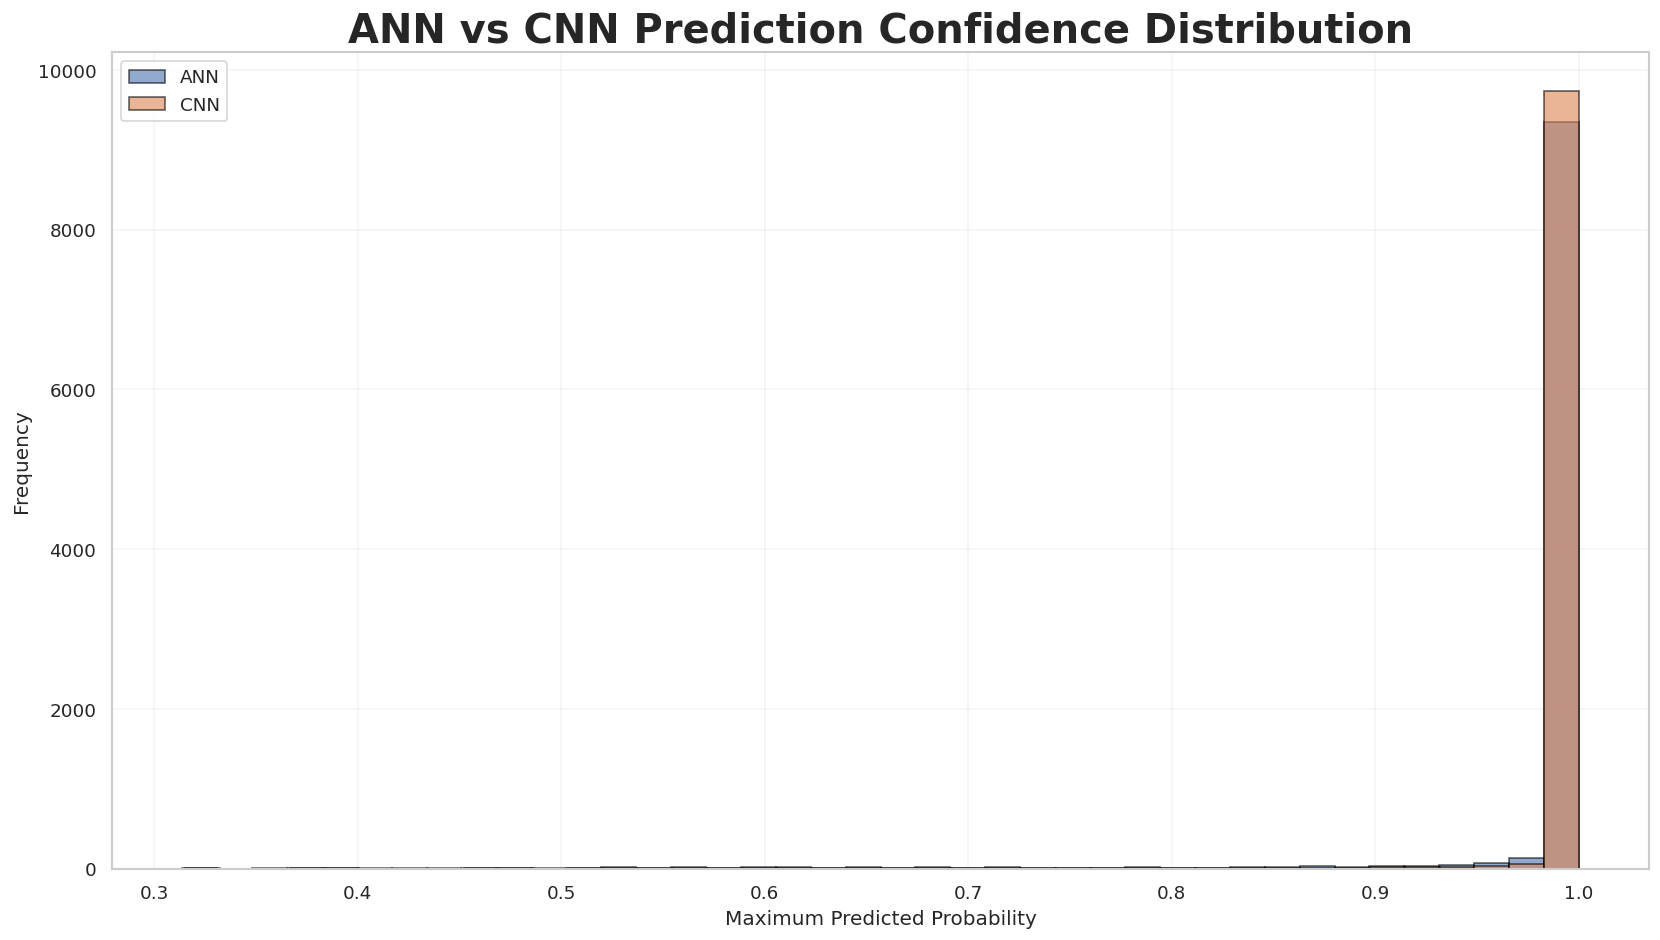

'images/ANN_vs_CNN_Prediction_Confidence_Distribution.png'

In [38]:
fig, ax = plt.subplots(
    figsize=(14, 8)
)

ax.hist(
    ann_confidence,
    bins=40,
    alpha=0.60,
    label="ANN",
    edgecolor="black"
)

ax.hist(
    cnn_confidence,
    bins=40,
    alpha=0.60,
    label="CNN",
    edgecolor="black"
)

title = "ANN vs CNN Prediction Confidence Distribution"

ax.set_title(
    title,
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Maximum Predicted Probability"
)

ax.set_ylabel(
    "Frequency"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

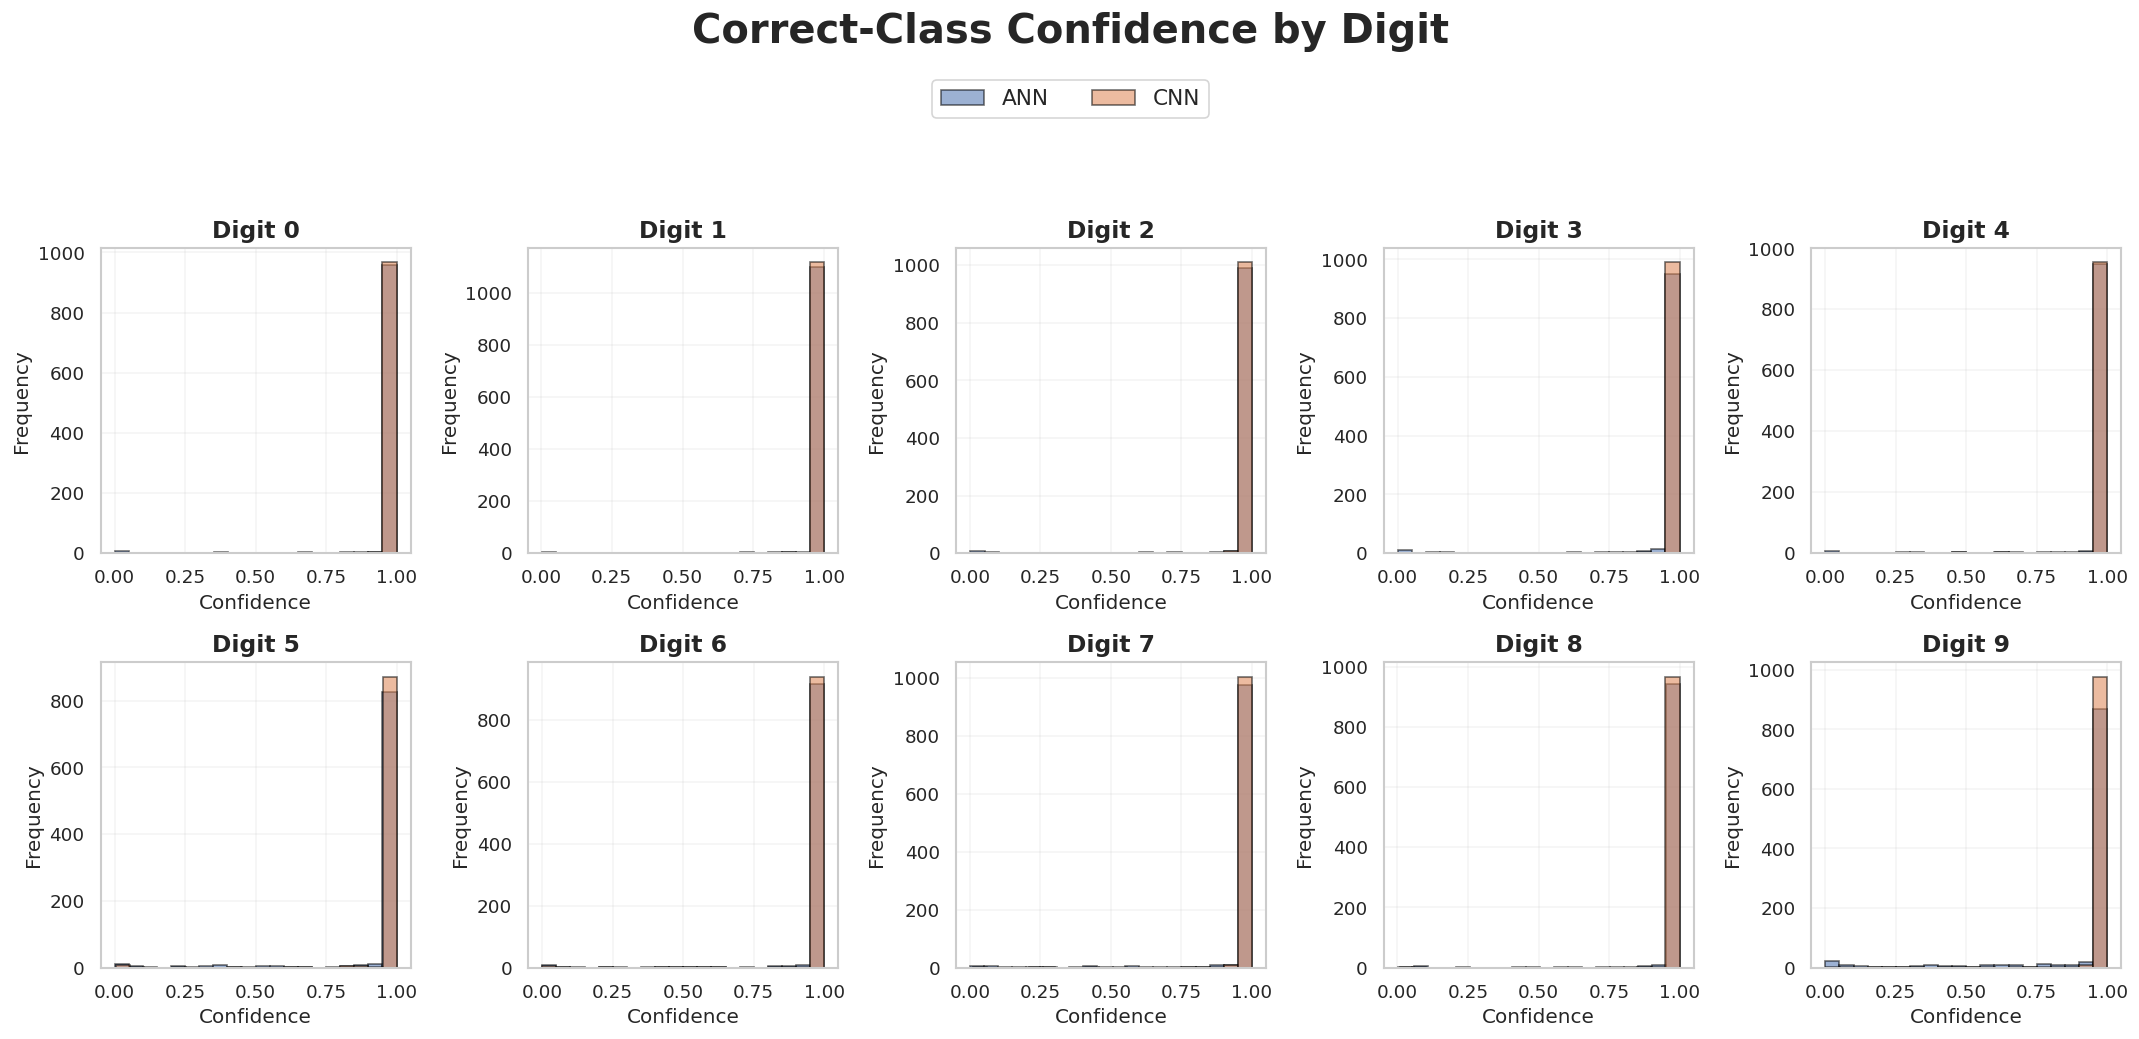

'images/Correct-Class_Confidence_by_Digit.png'

In [39]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

for digit, ax in enumerate(
    axes.ravel()
):
    ann_values = ann_correct_confidence[
        y_test == digit
    ]

    cnn_values = cnn_correct_confidence[
        y_test == digit
    ]

    ax.hist(
        ann_values,
        bins=20,
        alpha=0.55,
        label="ANN",
        edgecolor="black"
    )

    ax.hist(
        cnn_values,
        bins=20,
        alpha=0.55,
        label="CNN",
        edgecolor="black"
    )

    ax.set_title(
        f"Digit {digit}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Confidence")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.2)

title = "Correct-Class Confidence by Digit"

fig.legend(
    ["ANN", "CNN"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=13
)

fig.suptitle(
    title,
    fontsize=24,
    fontweight="bold",
    y=1.08
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

save_matplotlib(title, fig)

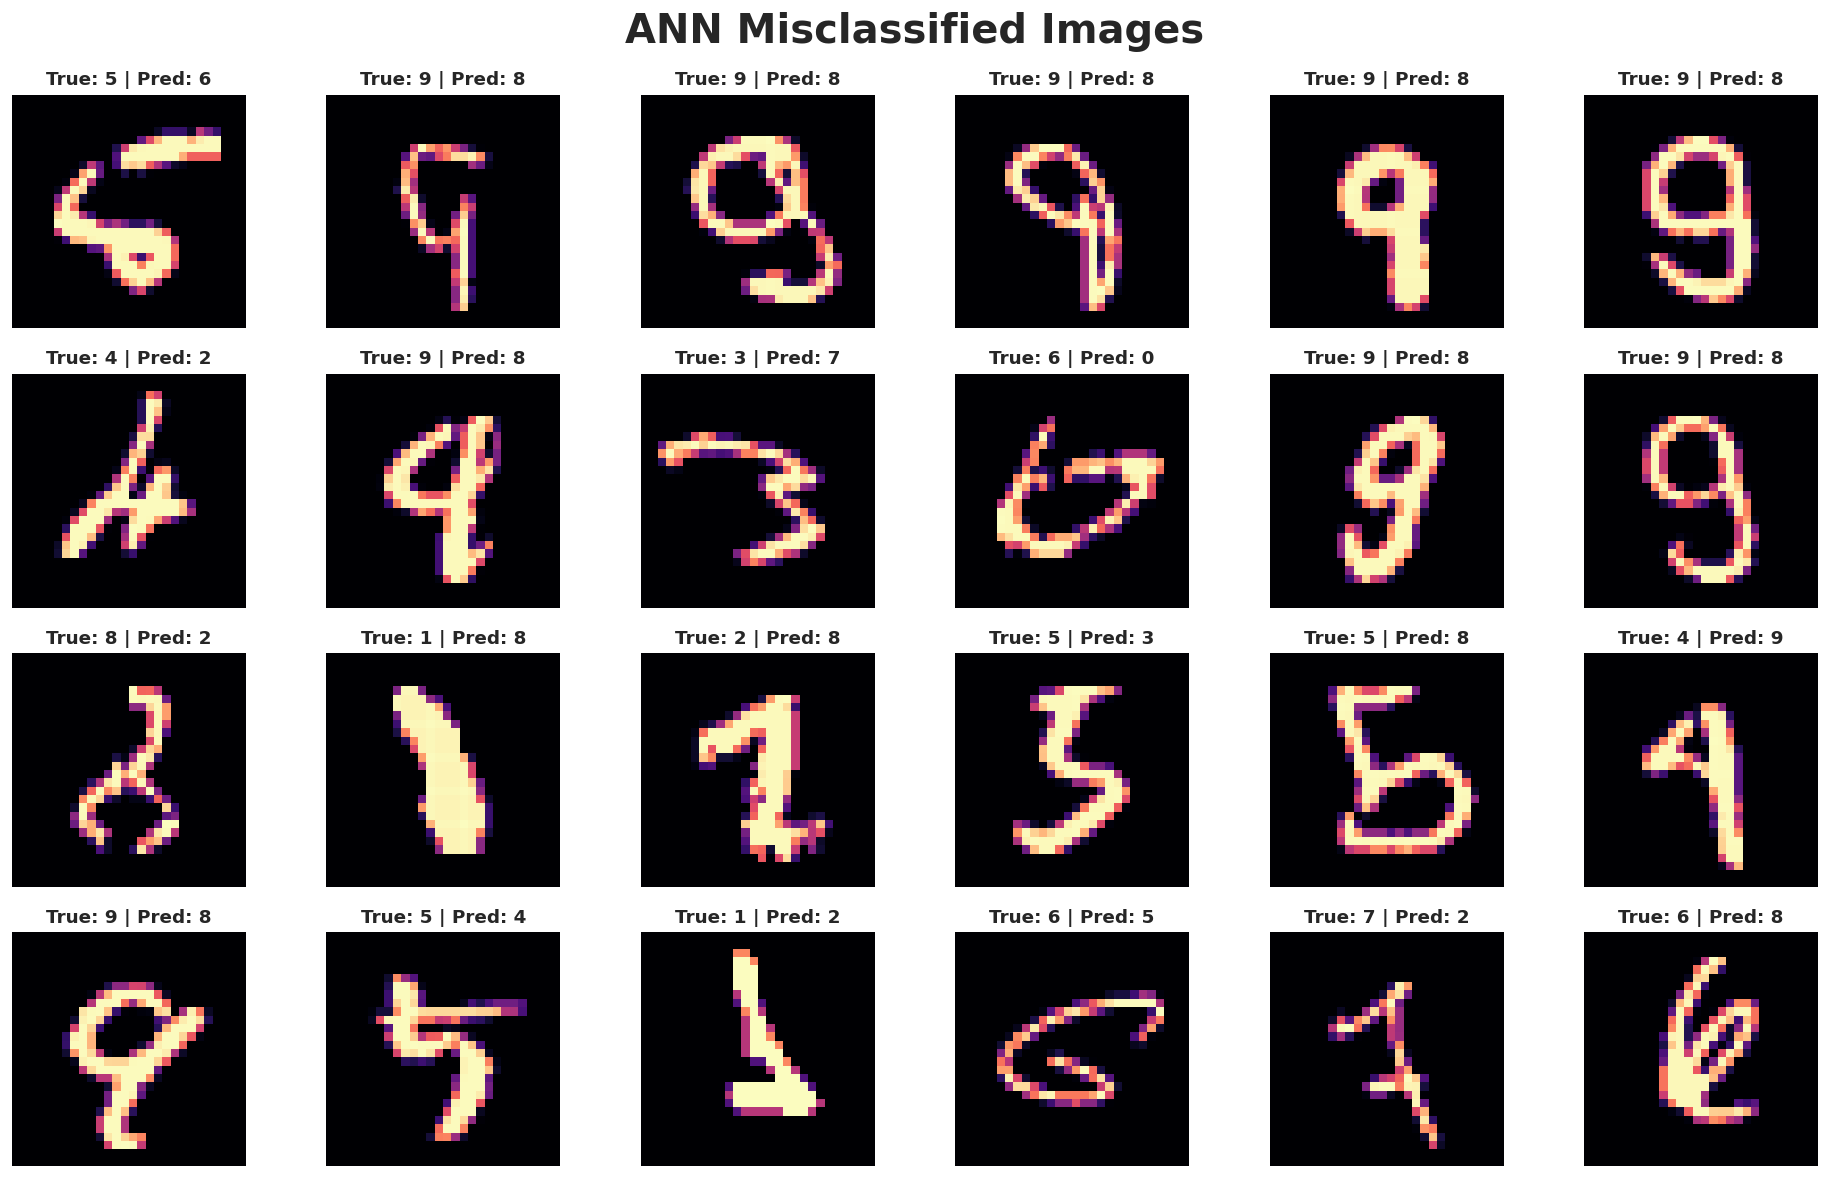

'images/ANN_Misclassified_Images.png'

In [40]:
ann_errors = np.where(
    ann_predictions != y_test
)[0]

sample_ann_errors = ann_errors[:24]

fig, axes = plt.subplots(
    4,
    6,
    figsize=(16, 10)
)

for ax, idx in zip(
    axes.ravel(),
    sample_ann_errors
):
    ax.imshow(
        X_test[idx],
        cmap="magma"
    )

    ax.set_title(
        f"True: {y_test[idx]} | Pred: {ann_predictions[idx]}",
        fontsize=11,
        fontweight="bold"
    )

    ax.axis("off")

title = "ANN Misclassified Images"

fig.suptitle(
    title,
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

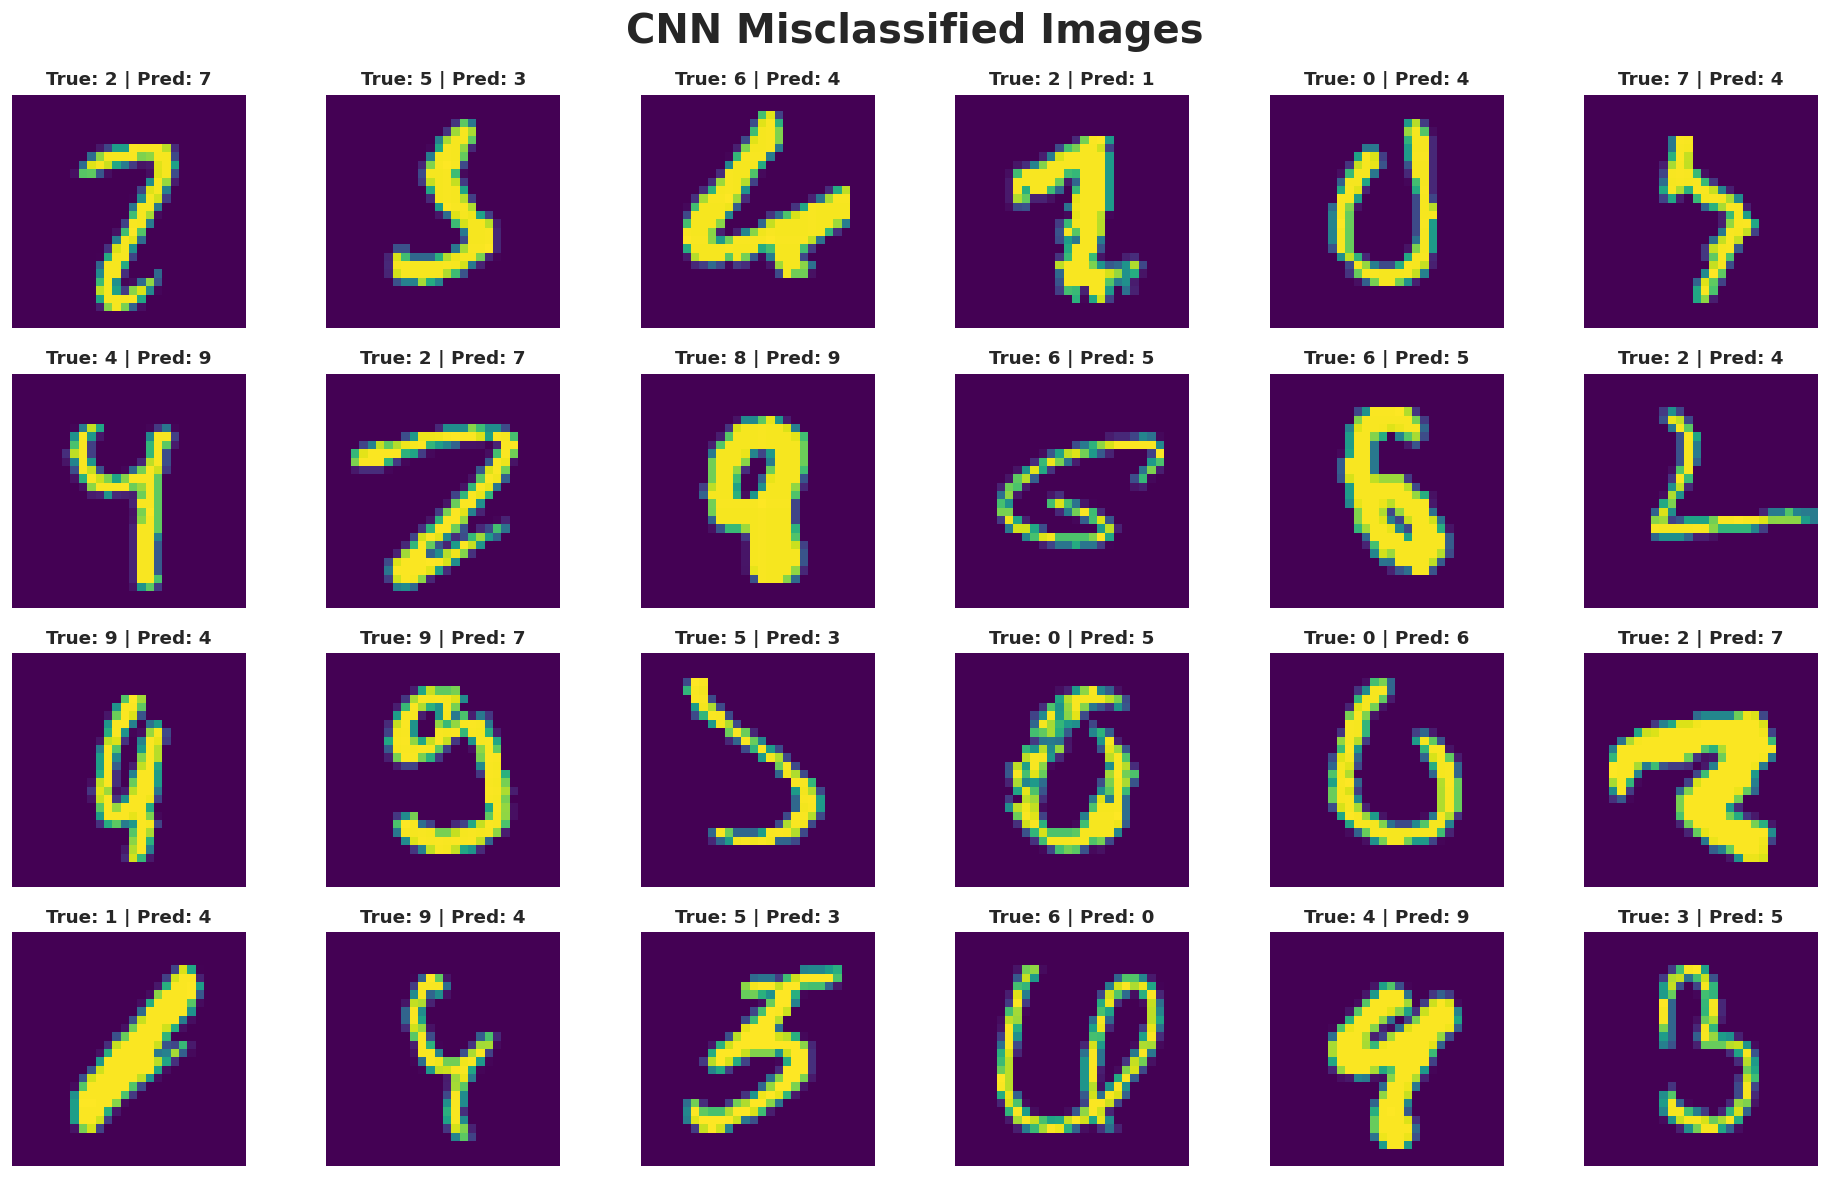

'images/CNN_Misclassified_Images.png'

In [41]:
cnn_errors = np.where(
    cnn_predictions != y_test
)[0]

sample_cnn_errors = cnn_errors[:24]

fig, axes = plt.subplots(
    4,
    6,
    figsize=(16, 10)
)

for ax, idx in zip(
    axes.ravel(),
    sample_cnn_errors
):
    ax.imshow(
        X_test[idx],
        cmap="viridis"
    )

    ax.set_title(
        f"True: {y_test[idx]} | Pred: {cnn_predictions[idx]}",
        fontsize=11,
        fontweight="bold"
    )

    ax.axis("off")

title = "CNN Misclassified Images"

fig.suptitle(
    title,
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [42]:
ann_feature_extractor = tf.keras.Model(
    inputs=ann.inputs,
    outputs=ann.layers[2].output
)

ann_features = ann_feature_extractor.predict(
    X_test_ann[:5000],
    verbose=0
)

print(
    "ANN Feature Shape:",
    ann_features.shape
)

ANN Feature Shape: (5000, 256)


In [43]:
cnn_input = tf.keras.Input(
    shape=(28, 28, 1)
)

x = cnn_input
cnn_feature_outputs = []

for layer in cnn.layers:
    x = layer(x)

    if isinstance(
        layer,
        tf.keras.layers.Conv2D
    ):
        cnn_feature_outputs.append(x)

cnn_feature_extractor = tf.keras.Model(
    inputs=cnn_input,
    outputs=cnn_feature_outputs
)

cnn_feature_maps = cnn_feature_extractor.predict(
    X_test_cnn[:1],
    verbose=0
)

for i, feature in enumerate(
    cnn_feature_maps
):
    print(
        f"Conv Feature Map {i + 1}:",
        feature.shape
    )

Conv Feature Map 1: (1, 26, 26, 32)
Conv Feature Map 2: (1, 24, 24, 64)
Conv Feature Map 3: (1, 10, 10, 128)


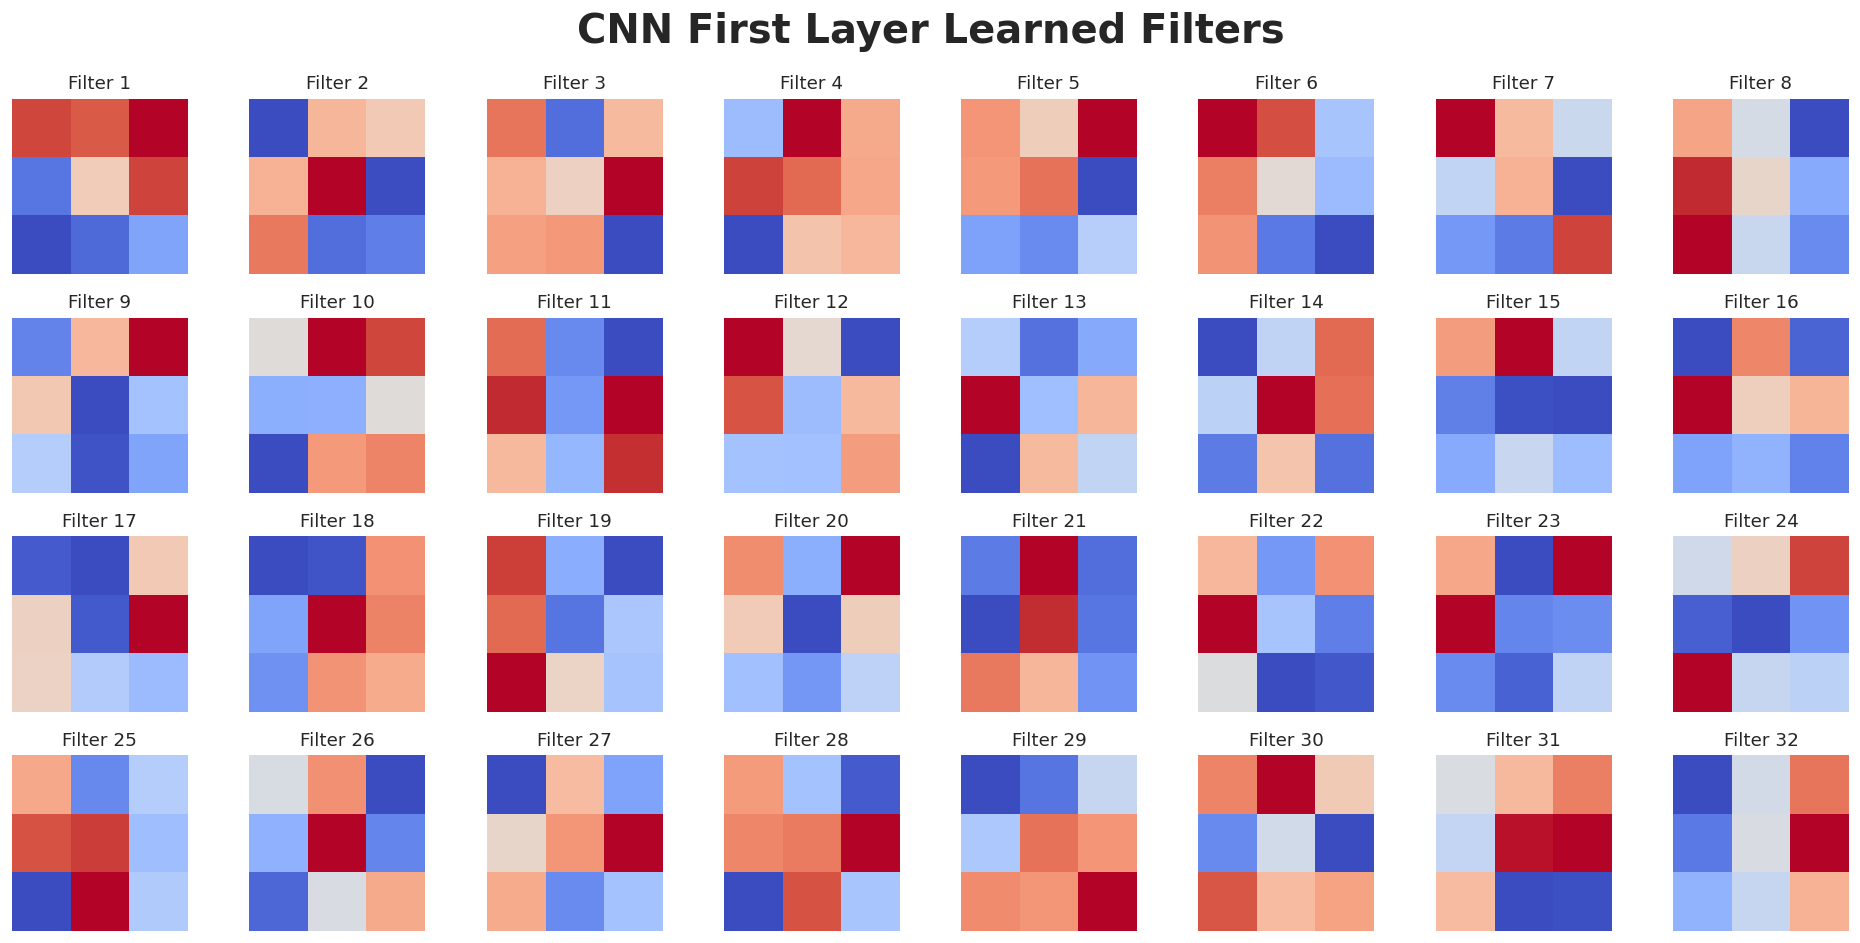

'images/CNN_First_Layer_Learned_Filters.png'

In [44]:
conv_layers = [
    layer
    for layer in cnn.layers
    if isinstance(
        layer,
        Conv2D
    )
]

first_conv_weights = conv_layers[0].get_weights()[0]

fig, axes = plt.subplots(
    4,
    8,
    figsize=(16, 8)
)

for i, ax in enumerate(
    axes.ravel()
):
    if i < first_conv_weights.shape[-1]:
        ax.imshow(
            first_conv_weights[:, :, 0, i],
            cmap="coolwarm"
        )

        ax.set_title(
            f"Filter {i + 1}",
            fontsize=11
        )

    ax.axis("off")

title = "CNN First Layer Learned Filters"

fig.suptitle(
    title,
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

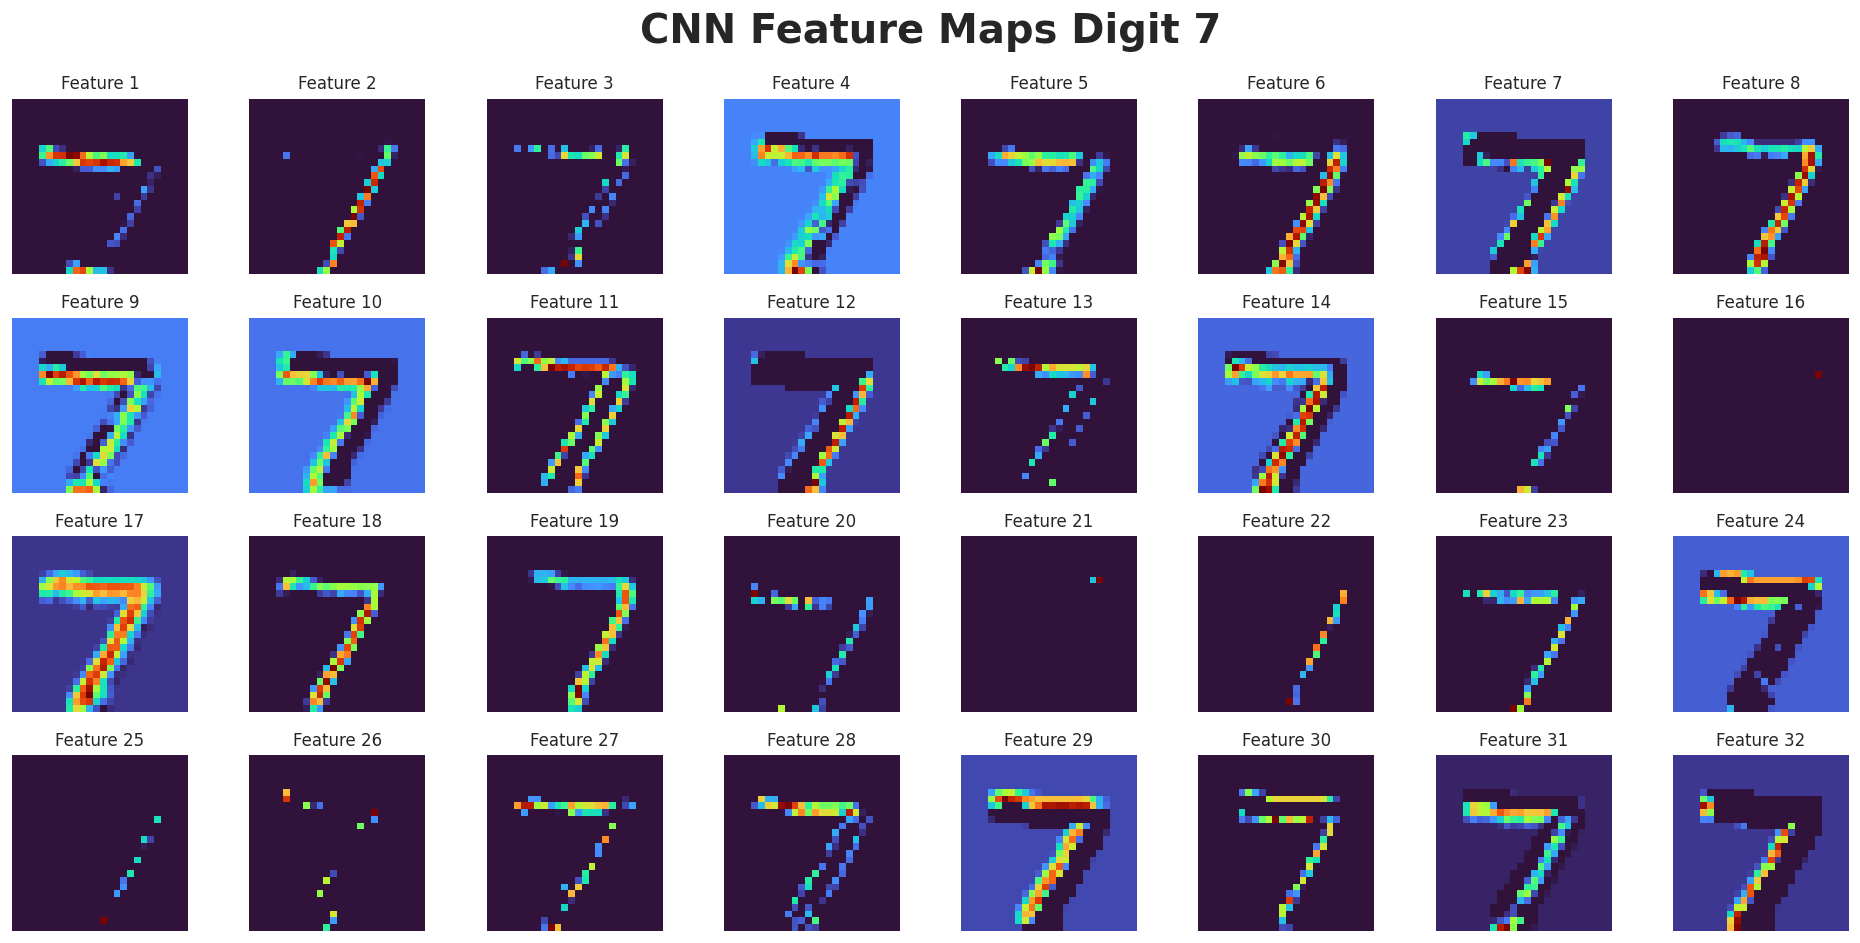

'images/CNN_Feature_Maps_Digit_7.png'

In [45]:
sample_index = 0

feature_outputs = cnn_feature_extractor.predict(
    X_test_cnn[sample_index:sample_index + 1],
    verbose=0
)

first_feature_map = feature_outputs[0][0]

fig, axes = plt.subplots(
    4,
    8,
    figsize=(16, 8)
)

for i, ax in enumerate(
    axes.ravel()
):
    if i < first_feature_map.shape[-1]:
        ax.imshow(
            first_feature_map[:, :, i],
            cmap="turbo"
        )

        ax.set_title(
            f"Feature {i + 1}",
            fontsize=10
        )

    ax.axis("off")

title = (
    f"CNN Feature Maps "
    f"Digit {y_test[sample_index]}"
)

fig.suptitle(
    title,
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [46]:
pca_ann_3d = PCA(
    n_components=3,
    random_state=SEED
)

ann_features_3d = pca_ann_3d.fit_transform(
    ann_features
)

print(
    "ANN PC1:",
    f"{pca_ann_3d.explained_variance_ratio_[0]:.2%}"
)

print(
    "ANN PC2:",
    f"{pca_ann_3d.explained_variance_ratio_[1]:.2%}"
)

print(
    "ANN PC3:",
    f"{pca_ann_3d.explained_variance_ratio_[2]:.2%}"
)

print(
    "ANN Total:",
    f"{pca_ann_3d.explained_variance_ratio_.sum():.2%}"
)

ANN PC1: 14.94%
ANN PC2: 12.40%
ANN PC3: 11.77%
ANN Total: 39.11%


In [47]:
ann_3d_df = pd.DataFrame({
    "PC1": ann_features_3d[:, 0],
    "PC2": ann_features_3d[:, 1],
    "PC3": ann_features_3d[:, 2],
    "Digit": y_test[:len(ann_features_3d)].astype(str)
})

title = "ANN Learned Feature Space 3D"

fig_ann_3d = px.scatter_3d(
    ann_3d_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Digit",
    opacity=0.65,
    hover_data=["Digit"],
    height=850,
    title=title
)

fig_ann_3d.update_traces(
    marker=dict(
        size=4
    )
)

fig_ann_3d.update_layout(
    title=dict(
        text=title,
        x=0.5,
        font=dict(
            size=25
        )
    ),
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    ),
    margin=dict(
        l=0,
        r=0,
        t=90,
        b=0
    )
)

fig_ann_3d.show()

save_plotly(
    fig_ann_3d,
    title
)

PNG export skipped: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



'images/ANN_Learned_Feature_Space_3D.html'

In [48]:
cnn_input = tf.keras.Input(
    shape=(28, 28, 1)
)

x = cnn_input

feature_outputs = []

for layer in cnn.layers:
    x = layer(x)

    if isinstance(layer, tf.keras.layers.Conv2D):
        feature_outputs.append(x)

cnn_feature_extractor = tf.keras.Model(
    inputs=cnn_input,
    outputs=feature_outputs
)

cnn_feature_maps = cnn_feature_extractor.predict(
    X_test_cnn[:1],
    verbose=0
)

for i, feature in enumerate(cnn_feature_maps):
    print(
        f"CNN Convolution Feature Map {i + 1}:",
        feature.shape
    )

CNN Convolution Feature Map 1: (1, 26, 26, 32)
CNN Convolution Feature Map 2: (1, 24, 24, 64)
CNN Convolution Feature Map 3: (1, 10, 10, 128)


In [49]:
cnn_feature_input = tf.keras.Input(
    shape=(28, 28, 1)
)

x = cnn_feature_input
flatten_output = None

for layer in cnn.layers:
    x = layer(x)

    if isinstance(
        layer,
        tf.keras.layers.Flatten
    ):
        flatten_output = x

cnn_flatten_extractor = tf.keras.Model(
    inputs=cnn_feature_input,
    outputs=flatten_output
)

print("Feature extractor created successfully")

Feature extractor created successfully


In [50]:
cnn_features = cnn_flatten_extractor.predict(
    X_test_cnn[:5000],
    verbose=0
)

print(
    "CNN Feature Shape:",
    cnn_features.shape
)

CNN Feature Shape: (5000, 3200)


In [51]:
cnn_features_flat = cnn_features.reshape(
    cnn_features.shape[0],
    -1
)

print(
    "Flattened CNN Feature Shape:",
    cnn_features_flat.shape
)

Flattened CNN Feature Shape: (5000, 3200)


In [52]:
pca_cnn_3d = PCA(
    n_components=3,
    random_state=SEED
)

cnn_features_3d = pca_cnn_3d.fit_transform(
    cnn_features_flat
)

print(
    "CNN PC1:",
    f"{pca_cnn_3d.explained_variance_ratio_[0]:.2%}"
)

print(
    "CNN PC2:",
    f"{pca_cnn_3d.explained_variance_ratio_[1]:.2%}"
)

print(
    "CNN PC3:",
    f"{pca_cnn_3d.explained_variance_ratio_[2]:.2%}"
)

print(
    "CNN Total:",
    f"{pca_cnn_3d.explained_variance_ratio_.sum():.2%}"
)

CNN PC1: 7.51%
CNN PC2: 6.46%
CNN PC3: 5.44%
CNN Total: 19.41%


In [53]:
cnn_3d_df = pd.DataFrame({
    "PC1": cnn_features_3d[:, 0],
    "PC2": cnn_features_3d[:, 1],
    "PC3": cnn_features_3d[:, 2],
    "Digit": y_test[:len(cnn_features_3d)].astype(str)
})

title = "CNN Learned Feature Space 3D"

fig_cnn_3d = px.scatter_3d(
    cnn_3d_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Digit",
    opacity=0.65,
    hover_data=["Digit"],
    height=850,
    title=title
)

fig_cnn_3d.update_traces(
    marker=dict(
        size=4
    )
)

fig_cnn_3d.update_layout(
    title=dict(
        text=title,
        x=0.5,
        font=dict(
            size=25
        )
    ),
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    ),
    margin=dict(
        l=0,
        r=0,
        t=90,
        b=0
    )
)

fig_cnn_3d.show()

save_plotly(
    fig_cnn_3d,
    title
)

PNG export skipped: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



'images/CNN_Learned_Feature_Space_3D.html'

In [54]:
ann_3d_comparison = pd.DataFrame({
    "PC1": ann_features_3d[:, 0],
    "PC2": ann_features_3d[:, 1],
    "PC3": ann_features_3d[:, 2],
    "Digit": y_test[:len(ann_features_3d)].astype(str),
    "Model": "ANN"
})

cnn_3d_comparison = pd.DataFrame({
    "PC1": cnn_features_3d[:, 0],
    "PC2": cnn_features_3d[:, 1],
    "PC3": cnn_features_3d[:, 2],
    "Digit": y_test[:len(cnn_features_3d)].astype(str),
    "Model": "CNN"
})

feature_space_3d = pd.concat(
    [
        ann_3d_comparison,
        cnn_3d_comparison
    ],
    ignore_index=True
)

title = "ANN vs CNN Learned Feature Space 3D"

fig_combined_3d = px.scatter_3d(
    feature_space_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Digit",
    symbol="Model",
    hover_data=[
        "Digit",
        "Model"
    ],
    opacity=0.65,
    height=900,
    title=title
)

fig_combined_3d.update_traces(
    marker=dict(
        size=3.5
    )
)

fig_combined_3d.update_layout(
    title=dict(
        text=title,
        x=0.5,
        font=dict(
            size=26
        )
    ),
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    ),
    legend_title="Digit / Model",
    margin=dict(
        l=0,
        r=0,
        t=95,
        b=0
    )
)

fig_combined_3d.show()

save_plotly(
    fig_combined_3d,
    title
)

PNG export skipped: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



'images/ANN_vs_CNN_Learned_Feature_Space_3D.html'

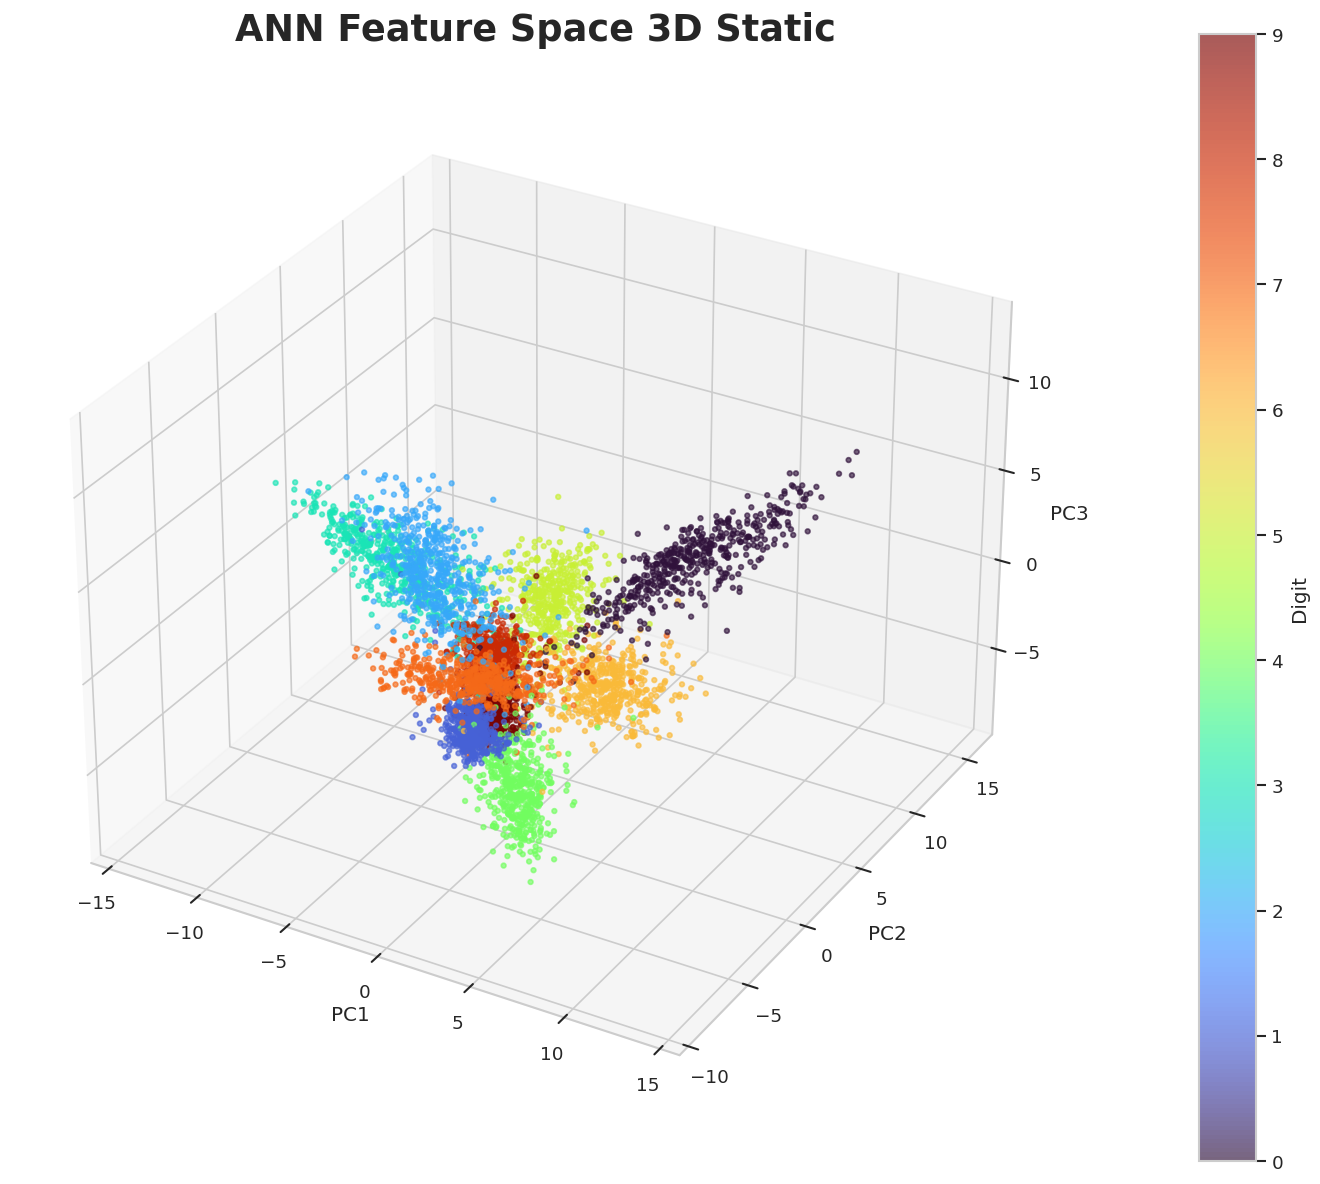

'images/ANN_Feature_Space_3D_Static.png'

In [55]:
fig = plt.figure(
    figsize=(12, 10)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    ann_features_3d[:, 0],
    ann_features_3d[:, 1],
    ann_features_3d[:, 2],
    c=y_test[:5000],
    cmap="turbo",
    s=8,
    alpha=0.65
)

title = "ANN Feature Space 3D Static"

ax.set_title(
    title,
    fontsize=22,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

fig.colorbar(
    scatter,
    ax=ax,
    pad=0.1,
    label="Digit"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

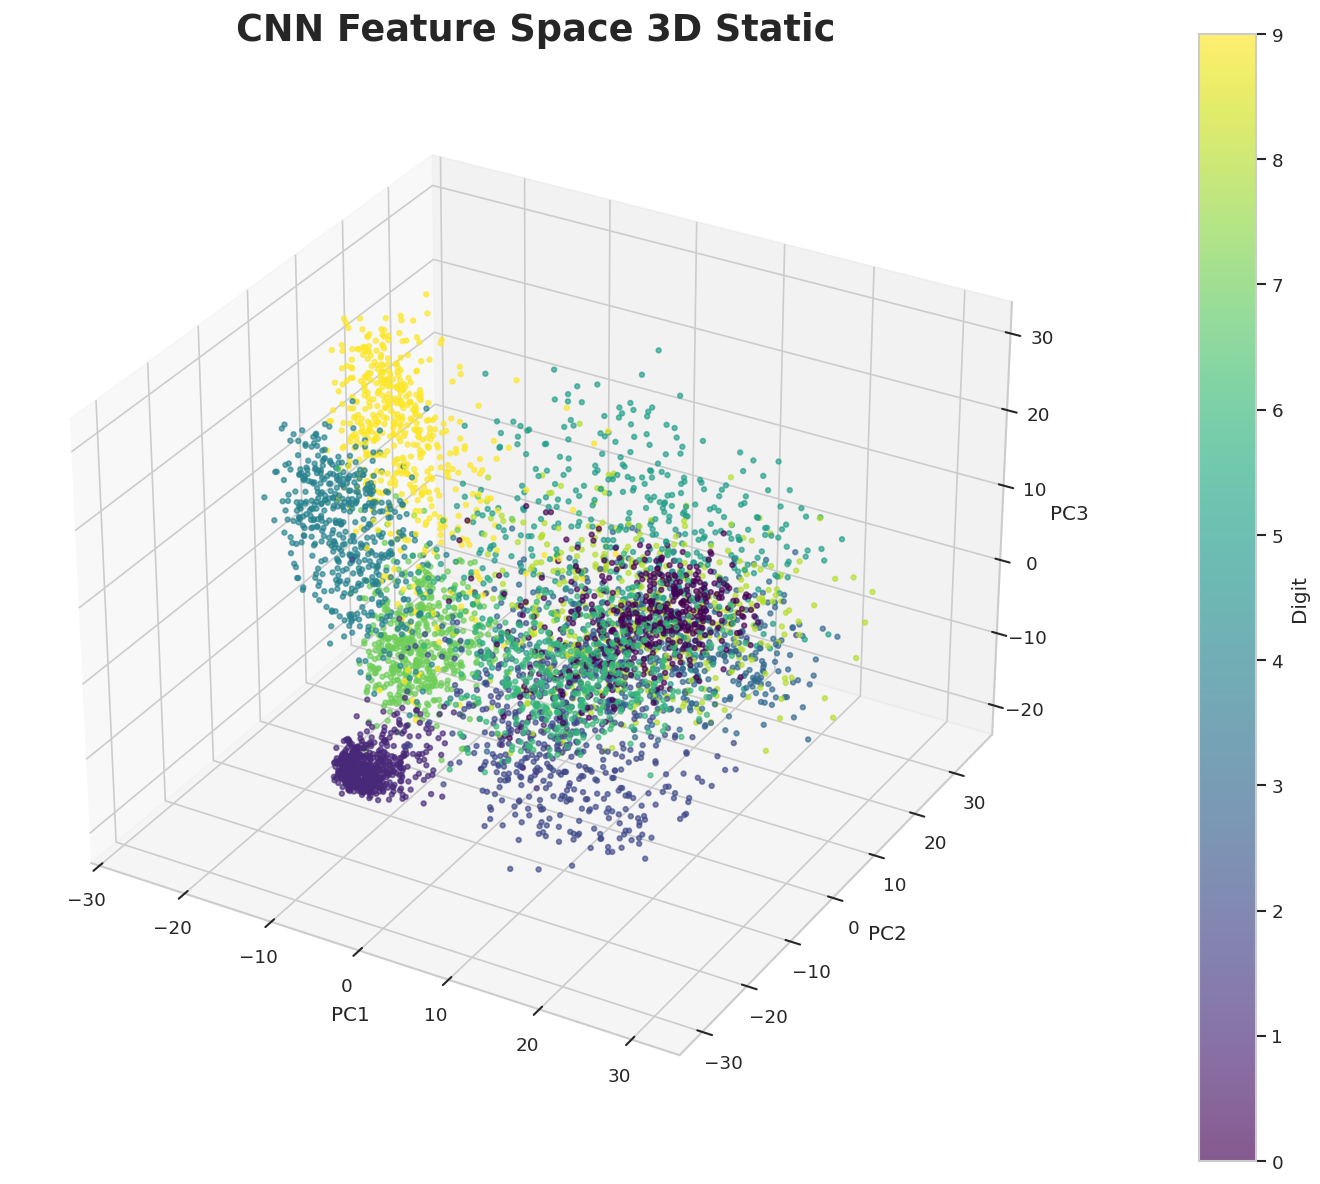

'images/CNN_Feature_Space_3D_Static.png'

In [56]:
fig = plt.figure(
    figsize=(12, 10)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    cnn_features_3d[:, 0],
    cnn_features_3d[:, 1],
    cnn_features_3d[:, 2],
    c=y_test[:5000],
    cmap="viridis",
    s=8,
    alpha=0.65
)

title = "CNN Feature Space 3D Static"

ax.set_title(
    title,
    fontsize=22,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

fig.colorbar(
    scatter,
    ax=ax,
    pad=0.1,
    label="Digit"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [57]:
variance_df = pd.DataFrame({
    "Component": [
        "PC1",
        "PC2",
        "PC3"
    ],
    "ANN": pca_ann_3d.explained_variance_ratio_,
    "CNN": pca_cnn_3d.explained_variance_ratio_
})

display(
    variance_df.style.format({
        "ANN": "{:.2%}",
        "CNN": "{:.2%}"
    })
)

,Component,ANN,CNN
0,PC1,14.94%,7.51%
1,PC2,12.40%,6.46%
2,PC3,11.77%,5.44%


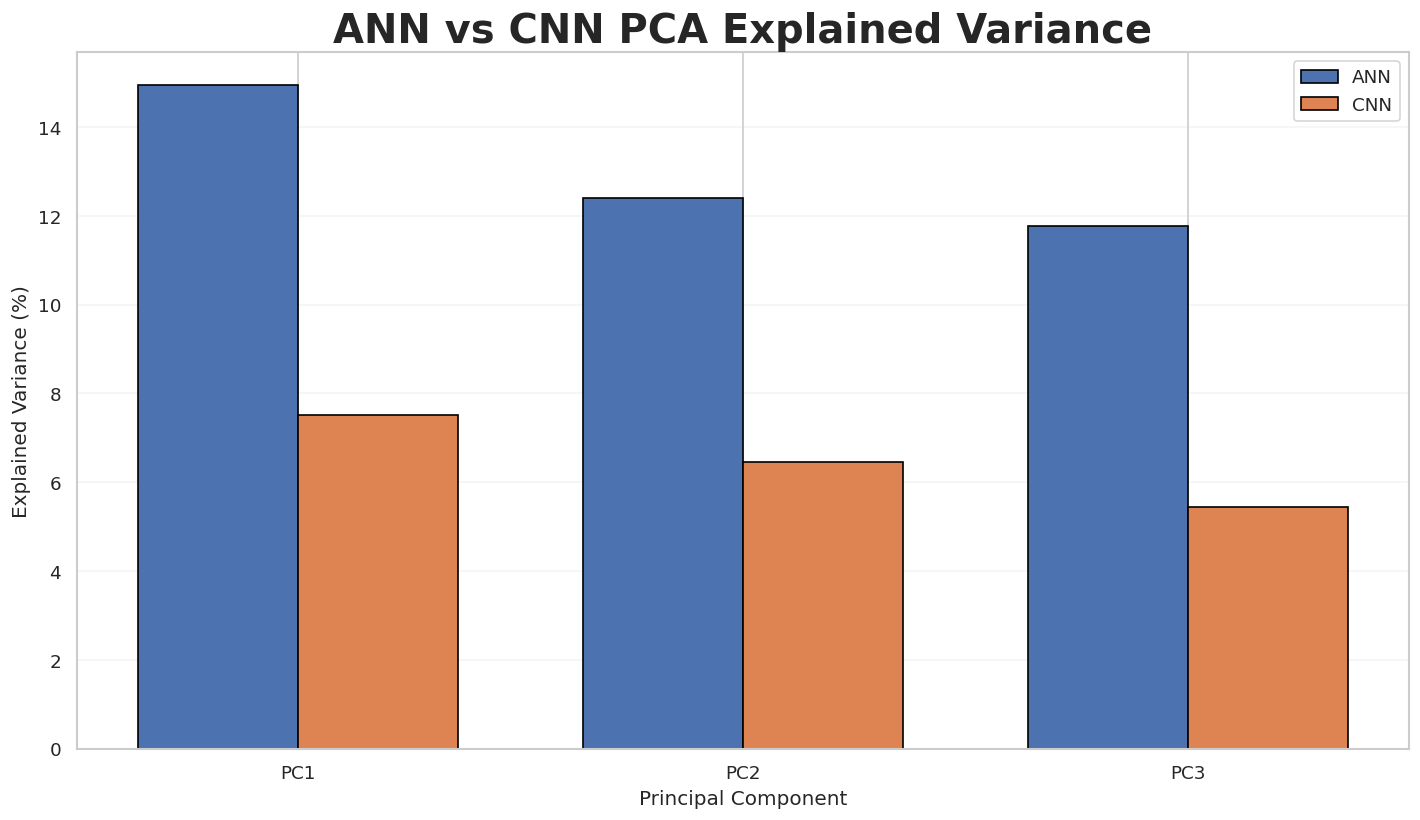

'images/ANN_vs_CNN_PCA_Explained_Variance.png'

In [58]:
x = np.arange(3)
width = 0.36

fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.bar(
    x - width / 2,
    pca_ann_3d.explained_variance_ratio_ * 100,
    width,
    label="ANN",
    edgecolor="black"
)

ax.bar(
    x + width / 2,
    pca_cnn_3d.explained_variance_ratio_ * 100,
    width,
    label="CNN",
    edgecolor="black"
)

title = "ANN vs CNN PCA Explained Variance"

ax.set_title(
    title,
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")

ax.set_xticks(
    x,
    ["PC1", "PC2", "PC3"]
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [59]:
feature_statistics = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN"
    ],
    "PC1 Variance": [
        pca_ann_3d.explained_variance_ratio_[0],
        pca_cnn_3d.explained_variance_ratio_[0]
    ],
    "PC2 Variance": [
        pca_ann_3d.explained_variance_ratio_[1],
        pca_cnn_3d.explained_variance_ratio_[1]
    ],
    "PC3 Variance": [
        pca_ann_3d.explained_variance_ratio_[2],
        pca_cnn_3d.explained_variance_ratio_[2]
    ],
    "Total 3D Variance": [
        pca_ann_3d.explained_variance_ratio_.sum(),
        pca_cnn_3d.explained_variance_ratio_.sum()
    ]
})

display(
    feature_statistics.style.format(
        {
            "PC1 Variance": "{:.2%}",
            "PC2 Variance": "{:.2%}",
            "PC3 Variance": "{:.2%}",
            "Total 3D Variance": "{:.2%}"
        }
    )
)

,Model,PC1 Variance,PC2 Variance,PC3 Variance,Total 3D Variance
0,ANN,14.94%,12.40%,11.77%,39.11%
1,CNN,7.51%,6.46%,5.44%,19.41%


In [60]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=[ann_params],
        y=[ann_test_accuracy * 100],
        mode="markers+text",
        text=["ANN"],
        textposition="top center",
        marker=dict(
            size=20
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[cnn_params],
        y=[cnn_test_accuracy * 100],
        mode="markers+text",
        text=["CNN"],
        textposition="top center",
        marker=dict(
            size=20
        )
    )
)

title = "ANN vs CNN Accuracy vs Parameter Count"

fig.update_layout(
    title=dict(
        text=title,
        x=0.5,
        font=dict(size=25)
    ),
    xaxis=dict(
        title="Trainable Parameters",
        type="log"
    ),
    yaxis=dict(
        title="Test Accuracy (%)"
    ),
    height=700
)

fig.show()

save_plotly(
    fig,
    title
)

PNG export skipped: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



'images/ANN_vs_CNN_Accuracy_vs_Parameter_Count.html'

In [61]:
confidence_3d = pd.DataFrame({
    "Class_1_2_3": ann_probabilities[:5000, 0],
    "Class_4_5_6": ann_probabilities[:5000, 1],
    "Class_7_8_9": ann_probabilities[:5000, 2],
    "Digit": y_test[:5000].astype(str)
})

title = "ANN Probability Feature Space 3D"

fig_probability = px.scatter_3d(
    confidence_3d,
    x="Class_1_2_3",
    y="Class_4_5_6",
    z="Class_7_8_9",
    color="Digit",
    opacity=0.65,
    hover_data=["Digit"],
    height=850,
    title=title
)

fig_probability.update_traces(
    marker=dict(
        size=4
    )
)

fig_probability.update_layout(
    title=dict(
        text=title,
        x=0.5,
        font=dict(size=25)
    ),
    scene=dict(
        xaxis_title="Probability Dimension 1",
        yaxis_title="Probability Dimension 2",
        zaxis_title="Probability Dimension 3"
    )
)

fig_probability.show()

save_plotly(
    fig_probability,
    title
)

PNG export skipped: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



'images/ANN_Probability_Feature_Space_3D.html'

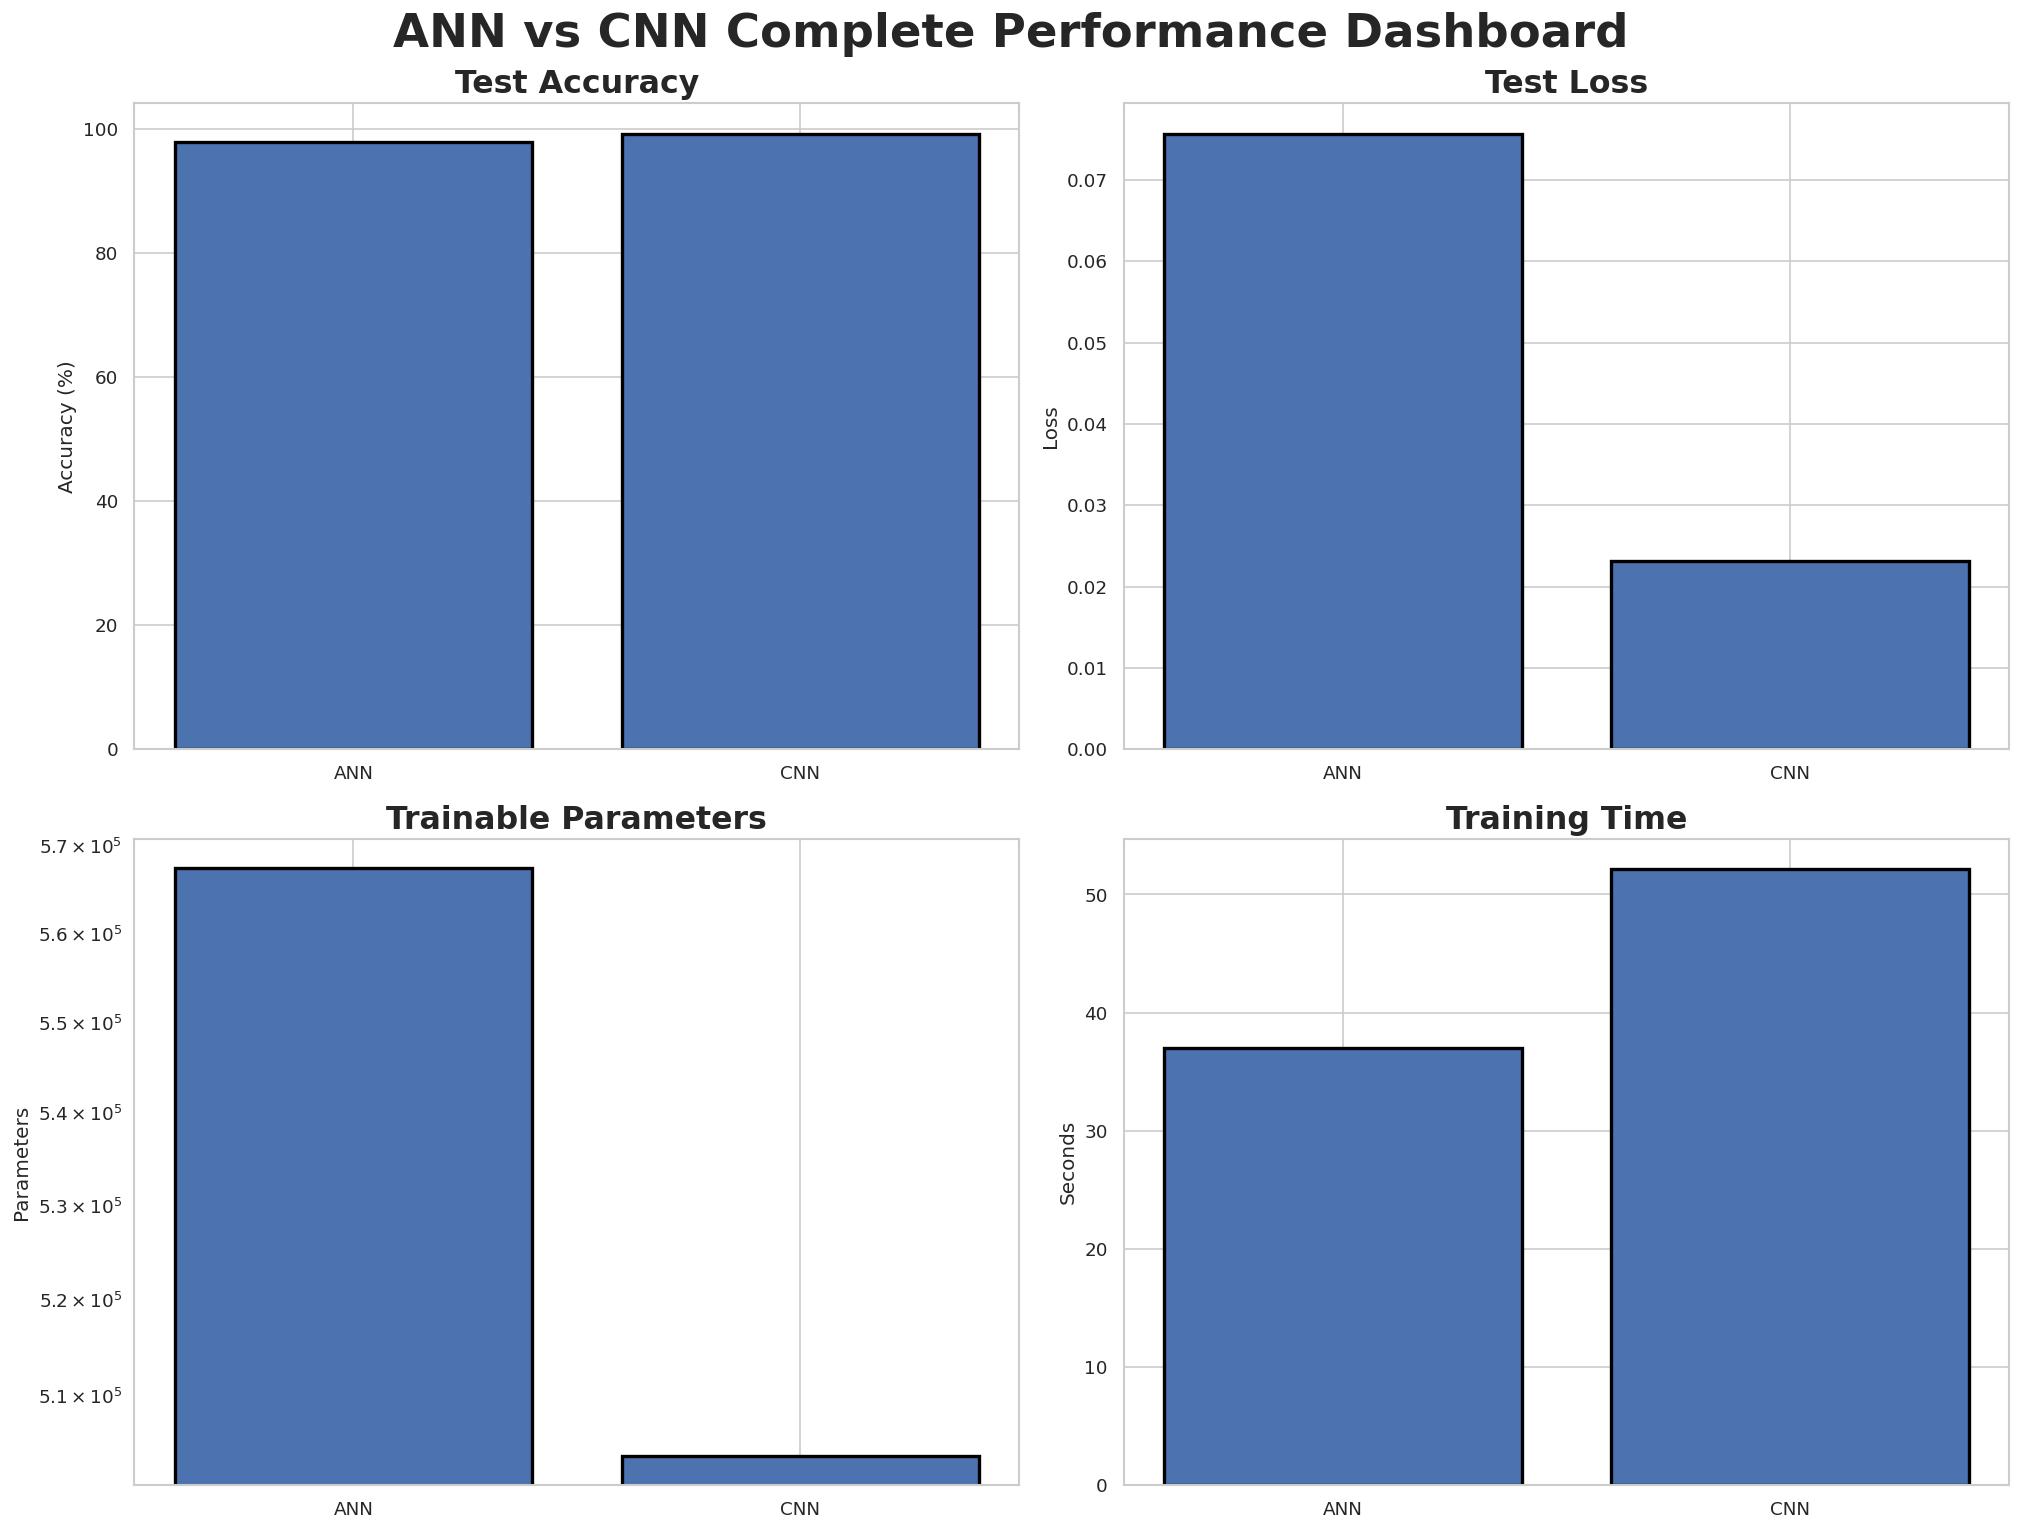

'images/ANN_vs_CNN_Complete_Performance_Dashboard.png'

In [62]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 13)
)

axes[0, 0].bar(
    models,
    [
        ann_test_accuracy * 100,
        cnn_test_accuracy * 100
    ],
    edgecolor="black",
    linewidth=2
)

axes[0, 0].set_title(
    "Test Accuracy",
    fontsize=19,
    fontweight="bold"
)

axes[0, 0].set_ylabel(
    "Accuracy (%)"
)

axes[0, 1].bar(
    models,
    [
        ann_test_loss,
        cnn_test_loss
    ],
    edgecolor="black",
    linewidth=2
)

axes[0, 1].set_title(
    "Test Loss",
    fontsize=19,
    fontweight="bold"
)

axes[0, 1].set_ylabel(
    "Loss"
)

axes[1, 0].bar(
    models,
    [
        ann_params,
        cnn_params
    ],
    edgecolor="black",
    linewidth=2
)

axes[1, 0].set_title(
    "Trainable Parameters",
    fontsize=19,
    fontweight="bold"
)

axes[1, 0].set_yscale("log")
axes[1, 0].set_ylabel(
    "Parameters"
)

axes[1, 1].bar(
    models,
    [
        ann_training_time,
        cnn_training_time
    ],
    edgecolor="black",
    linewidth=2
)

axes[1, 1].set_title(
    "Training Time",
    fontsize=19,
    fontweight="bold"
)

axes[1, 1].set_ylabel(
    "Seconds"
)

title = "ANN vs CNN Complete Performance Dashboard"

fig.suptitle(
    title,
    fontsize=28,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

save_matplotlib(title, fig)

In [63]:
accuracy_difference = (
    cnn_test_accuracy -
    ann_test_accuracy
)

parameter_ratio = (
    ann_params / cnn_params
)

error_ann = 1 - ann_test_accuracy
error_cnn = 1 - cnn_test_accuracy

summary = pd.DataFrame({
    "Metric": [
        "ANN Accuracy",
        "CNN Accuracy",
        "CNN Accuracy Advantage",
        "ANN Parameters",
        "CNN Parameters",
        "ANN/CNN Parameter Ratio",
        "ANN Error Rate",
        "CNN Error Rate"
    ],
    "Value": [
        f"{ann_test_accuracy:.4%}",
        f"{cnn_test_accuracy:.4%}",
        f"{accuracy_difference:.4%}",
        f"{ann_params:,}",
        f"{cnn_params:,}",
        f"{parameter_ratio:.2f}x",
        f"{error_ann:.4%}",
        f"{error_cnn:.4%}"
    ]
})

display(summary)

,Metric,Value
0,ANN Accuracy,97.9600%
1,CNN Accuracy,99.2800%
2,CNN Accuracy Advantage,1.3200%
3,ANN Parameters,"567,434"
4,CNN Parameters,"503,818"
5,ANN/CNN Parameter Ratio,1.13x
6,ANN Error Rate,2.0400%
7,CNN Error Rate,0.7200%


In [64]:
saved_files = sorted(
    os.listdir(IMAGE_DIR)
)

saved_df = pd.DataFrame({
    "Saved File": saved_files
})

display(saved_df)

print(
    f"Total files saved: {len(saved_files)}"
)

print(
    "Folder:",
    os.path.abspath(IMAGE_DIR)
)

,Saved File
0,ANN_Confusion_Matrix.png
1,ANN_Feature_Space_3D_Static.png
2,ANN_Learned_Feature_Space_3D.html
3,ANN_Learning_Curves.png
4,ANN_Misclassified_Images.png
5,ANN_Probability_Feature_Space_3D.html
6,ANN_vs_CNN_Accuracy_Across_Epochs.png
7,ANN_vs_CNN_Accuracy_vs_Parameter_Count.html
8,ANN_vs_CNN_Complete_Performance_Dashboard.png
9,ANN_vs_CNN_F1_Score_by_Digit.png


Total files saved: 29
Folder: /content/images


# ANN vs CNN — Final Understanding

## ANN

The ANN receives the MNIST image after flattening the 28 × 28 image into 784 numerical inputs.

The model therefore processes the image through dense connections.

The important characteristics are:

- Flattened image input
- Fully connected layers
- No convolutional weight sharing
- No explicit local receptive fields
- Spatial relationships are not directly preserved
- Parameter count can grow rapidly as image dimensions increase

## CNN

The CNN receives the image as a 28 × 28 × 1 tensor.

Convolutional filters move across local regions of the image.

The model therefore learns progressively richer visual patterns.

The important characteristics are:

- Two-dimensional image input
- Local receptive fields
- Convolutional filters
- Weight sharing
- Feature maps
- Pooling
- Hierarchical feature extraction
- Strong suitability for image data

## Feature Space

The 3D Plotly feature-space graphs use PCA to compress high-dimensional learned representations into three dimensions.

The goal is to visually inspect:

- Class clustering
- Class overlap
- Representation structure
- Separation between digit classes
- Differences between ANN and CNN learned representations

The absolute PC coordinates of the ANN and CNN should not be interpreted as the same coordinate system because PCA is fitted separately for each representation.

## Main Lesson

The important idea is not simply:

CNN is better than ANN.

The deeper idea is:

The architecture should match the structure of the data.

For image data, CNNs explicitly exploit spatial locality and repeated visual patterns. This is the core reason convolutional architectures are so useful for visual recognition.

## Saved Outputs

Every generated graph is automatically stored in:

images/

Matplotlib figures are saved as PNG.

Plotly figures are saved as:

- PNG
- HTML

The HTML versions are interactive and allow rotation, zooming, hovering, and exploration of the 3D feature spaces.